In [1]:
"""
Gene Neighborhood Analysis Pipeline
Fetches genomic neighborhoods, classifies genes via multi-tier API strategy,
and generates publication-quality aligned visualizations with fusion protein highlighting.
"""

import json
import re
import socket
import time
import requests
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple, Optional
from Bio import Entrez, SeqIO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrow

# Configuration

In [2]:
Entrez.email = "phitro@bu.edu"
Entrez.api_key = "ef936385f564d771552b54e79f25d637d407"

NCBI_HTTP_TIMEOUT_SEC = 20
NCBI_PROTEIN_TIMEOUT_SEC = 12
UNIPROT_TIMEOUT_SEC = 5
VERBOSE_STATUS = True


def log_status(message: str):
    """Print concise status updates for major pipeline/API steps."""
    if VERBOSE_STATUS:
        print(f"[info] {message}")

# Keep Entrez calls from hanging indefinitely on slow endpoints.
socket.setdefaulttimeout(NCBI_HTTP_TIMEOUT_SEC)

# Use editable TrueType fonts in vector outputs to keep text crisp in PDF viewers.
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'DejaVu Sans'

NEIGHBOR_WINDOW_BP = 15000
NUM_NEIGHBORS = 5
BASE_DISPLAY_BP = 5000
MAX_DISPLAY_BP = 7000       # Limit plotted context to +/-7 kb around target
MIN_SIDE_GENES = 3
MAX_SIDE_GENES = 8
INCLUDE_CONTEXT_GENE = True
MERGE_OVERLAPPING_TARGET_ROWS = True

# Colorblind-optimized palette with expanded blue-spectrum separation.
COLOR_MAP = {
    'Methyltransferase': '#AA4499',
    'Oxidoreductase': '#D55E00',
    'Hydrolase': '#88CCEE',
    'Ligase': '#009E73',
    'Lyase': '#E69F00',
    'Isomerase': '#AA3377',
    'Amidotransferase': '#CC79A7',
    'Transferase': '#44AA99',
    'Transporter': '#0072B2',
    'Regulation': '#6699CC',
    'ATPase/Chaperone': '#DDAA33',
    'Kinase': '#999933',
    'Glycosyltransferase': '#DDCC77',
    'Genome maintenance': '#332288',
    'Resistance': '#882255',
    'Cofactor biosynthesis': '#117733',
    'Gene expression': '#AA7744',
    'Unknown': '#BBBBBB'
}

CATEGORY_PRIORITY = [
    'Methyltransferase',
    'Oxidoreductase',
    'Hydrolase',
    'Ligase',
    'Lyase',
    'Isomerase',
    'Amidotransferase',
    'Transferase',
    'Transporter',
    'Regulation',
    'ATPase/Chaperone',
    'Kinase',
    'Glycosyltransferase',
    'Genome maintenance',
    'Resistance',
    'Cofactor biosynthesis',
    'Gene expression',
    'Unknown',
]

# Text rules are intentionally high-confidence only to avoid false positives.
KEYWORD_RULES = {
    'methyltransferase': 'Methyltransferase',
    'egtd': 'Methyltransferase',
    'sam-dependent': 'Methyltransferase',
    'methylase': 'Methyltransferase',
    'oxidoreductase': 'Oxidoreductase',
    'reductase': 'Oxidoreductase',
    'sulfoxide synthase': 'Oxidoreductase',
    'monooxygenase': 'Oxidoreductase',
    'luciferase-like': 'Oxidoreductase',
    'egtb': 'Oxidoreductase',
    'egt1': 'Oxidoreductase',
    'oxygenase': 'Oxidoreductase',
    'dehydrogenase': 'Oxidoreductase',
    'oxidase': 'Oxidoreductase',
    'hydrolase': 'Hydrolase',
    'esterase': 'Hydrolase',
    'lipase': 'Hydrolase',
    'peptidase': 'Hydrolase',
    'protease': 'Hydrolase',
    'isomerase': 'Isomerase',
    'racemase': 'Isomerase',
    'epimerase': 'Isomerase',
    'fmn-binding': 'Oxidoreductase',
    'flavin': 'Oxidoreductase',
    'rieske': 'Oxidoreductase',
    '2fe-2s': 'Oxidoreductase',
    '2fe2s': 'Oxidoreductase',
    'egta': 'Ligase',
    'cysteine ligase': 'Ligase',
    'glutamate--cysteine ligase': 'Ligase',
    'synthetase': 'Ligase',
    'lyase': 'Lyase',
    'egte': 'Lyase',
    'egt2': 'Lyase',
    'methylglyoxal synthase': 'Lyase',
    'amidotransferase': 'Amidotransferase',
    'egtc': 'Amidotransferase',
    'aminotransferase': 'Transferase',
    'aspartate aminotransferase': 'Transferase',
    'transaminase': 'Transferase',
    'aminotranferase': 'Transferase',
    'nucleotidyl transferase': 'Transferase',
    'nucleotidyltransferase': 'Transferase',
    'nucleotide transferase': 'Transferase',
    'prenyltransferase': 'Transferase',
    'chlorophyll synthetase': 'Transferase',
    'chlorophyll synthase': 'Transferase',
    'bacteriochlorophyll synthetase': 'Transferase',
    'bacteriochlorophyll synthase': 'Transferase',
    'acetyltransferase': 'Transferase',
    'phosphotransferase': 'Transferase',
    'rhodanese': 'Transferase',
    'sulfurtransferase': 'Transferase',
    'eanb': 'Transferase',
    'glycine cleavage system t protein': 'Transferase',
    'abc transporter': 'Transporter',
    'transporter': 'Transporter',
    'permease': 'Transporter',
    'channel protein': 'Transporter',
    'mip family': 'Transporter',
    'efflux': 'Transporter',
    'major facilitator': 'Transporter',
    'mfs': 'Transporter',
    'port family': 'Transporter',
    'port protein': 'Transporter',
    'type ix secretion system': 'Transporter',
    't9ss': 'Transporter',
    'transcription factor': 'Regulation',
    'transcriptional regulator': 'Regulation',
    'response regulator': 'Regulation',
    'repressor': 'Regulation',
    'activator': 'Regulation',
    'pas sensor protein': 'Regulation',
    'pknh-like extracellular domain': 'Regulation',
    'extracellular sensor domain': 'Regulation',
    'rava': 'ATPase/Chaperone',
    'viaa': 'ATPase/Chaperone',
    'aaa atpase': 'ATPase/Chaperone',
    'aaa-': 'ATPase/Chaperone',
    'atpase associated with various cellular activities': 'ATPase/Chaperone',
    'chaperone': 'ATPase/Chaperone',
    'heat shock protein': 'ATPase/Chaperone',
    'hsp70': 'ATPase/Chaperone',
    'hsp90': 'ATPase/Chaperone',
    'kinase': 'Kinase',
    'cell cycle': 'Kinase',
    'mitosis': 'Kinase',
    'mik1': 'Kinase',
    'glycosyl transferase': 'Glycosyltransferase',
    'glycosyltransferase': 'Glycosyltransferase',
    'mannosyltransferase': 'Glycosyltransferase',
    'dna replication': 'Genome maintenance',
    'replication protein a': 'Genome maintenance',
    'ssb1': 'Genome maintenance',
    'telomere': 'Genome maintenance',
    'telomeric-binding': 'Genome maintenance',
    'transposase': 'Genome maintenance',
    'integrase': 'Genome maintenance',
    'recombinase': 'Genome maintenance',
    'helicase': 'Genome maintenance',
    'endonuclease': 'Genome maintenance',
    'exonuclease': 'Genome maintenance',
    'chloramphenicol resistance': 'Resistance',
    'aminoglycoside phosphotransferase': 'Resistance',
    'drug resistance': 'Resistance',
    'multidrug resistance': 'Resistance',
    'cofactor biosynthesis': 'Cofactor biosynthesis',
    'iron-molybdenum cofactor biosynthesis': 'Cofactor biosynthesis',
    'molybdenum cofactor biosynthesis': 'Cofactor biosynthesis',
    'translation elongation factor': 'Gene expression',
    'elongation factor g': 'Gene expression',
    'ppr repeat': 'Gene expression',
    'photosystem i assembly protein ycf3': 'ATPase/Chaperone',
    'ycf3': 'ATPase/Chaperone',
}

PFAM_MAP = {
    'PF01031': 'Methyltransferase',
    'PF08241': 'Methyltransferase',
    'PF01553': 'Methyltransferase',
    'PF04055': 'Oxidoreductase',
    'PF05114': 'Oxidoreductase',
    'PF00355': 'Oxidoreductase',
    'PF01266': 'Lyase',
    'PF00583': 'Amidotransferase',
    'PF00005': 'Transporter',
    'PF17868': 'ATPase/Chaperone',
    'PF12592': 'ATPase/Chaperone',
    'PF20030': 'ATPase/Chaperone',
    'PF20265': 'ATPase/Chaperone',
    'PF00069': 'Kinase',
    'PF00535': 'Glycosyltransferase',
    'PF00581': 'Transferase',
}

UNIPROT_SEARCH_FIELDS = 'protein_name,keyword,go,cc_function,ec,xref_pfam,xref_brenda'

GENE_SYMBOL_PATTERNS = [
    (r'\b(egt[abcde12])\b', lambda m: m.group(1).capitalize()),
    (r'\b(ovoa)\b', lambda m: 'OvoA'),
    (r'\b(eanb)\b', lambda m: 'EanB'),
    (r'\b(cames)\b', lambda m: 'CaMES'),
    (r'\b(memes)\b', lambda m: 'MeMES')
]

# Legend ordering: choose 'logical' or 'alphabetical'.
LEGEND_ORDER_MODE = 'logical'
LEGEND_LOGICAL_ORDER = [
    'Methyltransferase',
    'Oxidoreductase',
    'Hydrolase',
    'Ligase',
    'Lyase',
    'Isomerase',
    'Amidotransferase',
    'Transferase',
    'Cofactor biosynthesis',
    'Transporter',
    'ATPase/Chaperone',
    'Kinase',
    'Genome maintenance',
    'Regulation',
    'Gene expression',
    'Glycosyltransferase',
    'Resistance',
    'Unknown',
]

In [3]:
# Merge tuning parameters
MERGE_DISTANCE_FACTOR = 1.7
MERGE_CONTEXT_BP = MAX_DISPLAY_BP
MERGE_FORCE_TARGETS_RIGHT = True

# API WRAPPERS

In [4]:
ASSEMBLY_TO_NUCCORE_CACHE: Dict[str, List[str]] = {}
UNIPROT_CACHE: Dict[str, Dict] = {}
NCBI_PROTEIN_CACHE: Dict[str, List[str]] = {}
API_CALL_LOG: List[Dict] = []


def _is_missing(value) -> bool:
    if value is None:
        return True
    if isinstance(value, float) and np.isnan(value):
        return True
    value_str = str(value).strip()
    return value_str == '' or value_str.lower() == 'nan'


def _normalize_gene_tag(value: Optional[str]) -> str:
    if _is_missing(value):
        return ''
    token = str(value).strip().upper()
    if token.startswith('SPOM_'):
        token = token[5:]
    return token


def _normalize_protein_id(value: Optional[str]) -> str:
    if _is_missing(value):
        return ''
    return str(value).strip().split('.')[0].upper()


def _is_likely_remote_protein_id(value: str) -> bool:
    """Skip expensive remote lookups for local-style gene ids (e.g. SPBC660.12c)."""
    if not value:
        return False
    if _looks_like_uniprot_accession(value):
        return True
    return bool(re.match(r'^(WP|NP|YP|XP|AP|QNP)_\d+$', value)) or bool(
        re.match(r'^[A-Z]{3}\d{5,6}$', value)
    )


def _looks_like_uniprot_accession(value: str) -> bool:
    if not value or '_' in value:
        return False
    return bool(
        re.match(
            r'^(?:[OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9][A-Z][A-Z0-9]{2}[0-9]|[A-NR-Z][0-9][A-Z][A-Z0-9]{6}[0-9])$',
            value
        )
    )


def _extract_feature_tags(feature) -> set:
    tags = set()
    for key in ('locus_tag', 'old_locus_tag', 'gene', 'gene_synonym', 'standard_name'):
        for value in feature.qualifiers.get(key, []):
            cleaned = _normalize_gene_tag(value)
            if cleaned:
                tags.add(cleaned)
    return tags


def _feature_overlap(a_start: int, a_end: int, b_start: int, b_end: int) -> int:
    left = max(a_start, b_start)
    right = min(a_end, b_end)
    return max(0, right - left)


def _extract_uniprot_text_terms(entry: Dict) -> List[str]:
    terms: List[str] = []

    def _add_term(value: Optional[str]):
        if value and value not in terms:
            terms.append(value)

    description = entry.get('proteinDescription', {})
    recommended_name = description.get('recommendedName', {})
    if recommended_name.get('fullName'):
        _add_term(recommended_name['fullName'].get('value'))

    for name_group in ('alternativeNames', 'submissionNames'):
        for item in description.get(name_group, []):
            if item.get('fullName'):
                _add_term(item['fullName'].get('value'))

    for keyword in entry.get('keywords', []):
        _add_term(keyword.get('name'))
    for comment in entry.get('comments', []):
        if comment.get('commentType') not in {'FUNCTION', 'DOMAIN', 'SIMILARITY'}:
            continue
        for text_obj in comment.get('texts', []):
            _add_term(text_obj.get('value'))

    for xref in entry.get('uniProtKBCrossReferences', []):
        if xref.get('database') != 'GO':
            continue
        for prop in xref.get('properties', []):
            if prop.get('key') == 'GoTerm':
                go_term = prop.get('value', '')
                _add_term(go_term.split(':', 1)[-1])
    for xref in entry.get('uniProtKBCrossReferences', []):
        db_name = str(xref.get('database', '')).strip()
        xref_id = str(xref.get('id', '')).strip()
        if db_name in {'Rhea', 'BRENDA'} and xref_id:
            _add_term(f'{db_name}:{xref_id}')

    return terms


def _extract_uniprot_domain_terms(entry: Dict) -> List[str]:
    terms: List[str] = []

    def _add_term(value: Optional[str]):
        text = str(value).strip() if value is not None else ''
        if text and text not in terms:
            terms.append(text)

    for feature in entry.get('features', []):
        feature_type = str(feature.get('type', '')).strip()
        if feature_type not in {'Domain', 'Region', 'Repeat', 'Motif'}:
            continue
        _add_term(feature_type)
        _add_term(feature.get('description'))

    for comment in entry.get('comments', []):
        if comment.get('commentType') not in {'DOMAIN', 'SIMILARITY'}:
            continue
        for text_obj in comment.get('texts', []):
            _add_term(text_obj.get('value'))

    domain_dbs = {
        'InterPro', 'Pfam', 'PROSITE', 'SMART', 'CDD', 'SUPFAM',
        'Gene3D', 'NCBIfam', 'PANTHER', 'HAMAP', 'FunFam'
    }
    for xref in entry.get('uniProtKBCrossReferences', []):
        db_name = str(xref.get('database', '')).strip()
        if db_name not in domain_dbs:
            continue
        _add_term(db_name)
        _add_term(xref.get('id'))
        for prop in xref.get('properties', []):
            _add_term(prop.get('value'))

    return terms


def _extract_uniprot_ec_numbers(entry: Dict) -> List[str]:
    ec_numbers: List[str] = []

    def _add_ec(value: Optional[str]):
        if not value:
            return
        ec = str(value).strip()
        if ec and ec not in ec_numbers:
            ec_numbers.append(ec)

    description = entry.get('proteinDescription', {})
    recommended_name = description.get('recommendedName', {})
    for ec_item in recommended_name.get('ecNumbers', []):
        _add_ec(ec_item.get('value'))

    for name_group in ('alternativeNames', 'submissionNames'):
        for item in description.get(name_group, []):
            for ec_item in item.get('ecNumbers', []):
                _add_ec(ec_item.get('value'))

    for xref in entry.get('uniProtKBCrossReferences', []):
        if str(xref.get('database', '')).strip() != 'EC':
            continue
        _add_ec(xref.get('id'))

    return ec_numbers


def _build_uniprot_payload(entry: Dict, source: str) -> Dict:
    pfam_ids = [
        xref['id']
        for xref in entry.get('uniProtKBCrossReferences', [])
        if xref.get('database') == 'Pfam'
    ]
    rhea_ids = [
        str(xref.get('id')).strip()
        for xref in entry.get('uniProtKBCrossReferences', [])
        if xref.get('database') == 'Rhea' and str(xref.get('id', '')).strip()
    ]
    brenda_ids = [
        str(xref.get('id')).strip()
        for xref in entry.get('uniProtKBCrossReferences', [])
        if xref.get('database') == 'BRENDA' and str(xref.get('id', '')).strip()
    ]
    return {
        'pfam_ids': pfam_ids,
        'text_terms': _extract_uniprot_text_terms(entry),
        'domain_terms': _extract_uniprot_domain_terms(entry),
        'ec_numbers': _extract_uniprot_ec_numbers(entry),
        'rhea_ids': list(dict.fromkeys(rhea_ids)),
        'brenda_ids': list(dict.fromkeys(brenda_ids)),
        'source': source,
    }


def fetch_genbank_slice(accession: str, start: int, end: int,
                        retries: int = 3) -> Optional[List]:
    """Fetch a GenBank record slice with retries."""
    for attempt in range(retries):
        t0 = time.time()
        try:
            with Entrez.efetch(
                db='nuccore',
                id=accession,
                rettype='gbwithparts',
                retmode='text',
                seq_start=max(1, start),
                seq_stop=end
            ) as handle:
                records = list(SeqIO.parse(handle, 'genbank'))

            API_CALL_LOG.append({
                'api': 'ncbi_efetch_slice',
                'id': accession,
                'status': 'ok' if records else 'empty',
                'elapsed_sec': round(time.time() - t0, 3)
            })

            if records:
                time.sleep(0.11)
                return records
            raise ValueError('No records returned for slice fetch')
        except Exception as e:
            API_CALL_LOG.append({
                'api': 'ncbi_efetch_slice',
                'id': accession,
                'status': f'error:{type(e).__name__}',
                'elapsed_sec': round(time.time() - t0, 3)
            })
            if attempt < retries - 1:
                time.sleep(1.5 * (2 ** attempt))
            else:
                print(f"Failed to fetch {accession}[{start}:{end}]: {e}")
                return None


def resolve_nuccore_candidates(genome_accession: str,
                               genbank_id: Optional[str] = None) -> List[str]:
    """Resolve assembly or GenBank identifiers to nuccore fetch candidates."""
    candidates = []

    if not _is_missing(genome_accession):
        genome_accession = str(genome_accession).strip()
        if not genome_accession.startswith(('GCF_', 'GCA_')):
            candidates.append(genome_accession)
        elif genome_accession in ASSEMBLY_TO_NUCCORE_CACHE:
            candidates.extend(ASSEMBLY_TO_NUCCORE_CACHE[genome_accession])
        else:
            resolved_ids = []
            try:
                # Assembly IDs (GCF/GCA) need to be mapped to nuccore record IDs first.
                with Entrez.esearch(
                    db='assembly',
                    term=f'{genome_accession}[Assembly Accession]',
                    retmode='xml'
                ) as search_handle:
                    search_record = Entrez.read(search_handle)

                assembly_ids = search_record.get('IdList', [])
                if assembly_ids:
                    with Entrez.elink(
                        dbfrom='assembly',
                        db='nuccore',
                        id=assembly_ids[0],
                        retmode='xml'
                    ) as link_handle:
                        link_record = Entrez.read(link_handle)

                    for linkset in link_record:
                        for linkset_db in linkset.get('LinkSetDb', []):
                            for link in linkset_db.get('Link', []):
                                nuccore_id = link.get('Id')
                                if nuccore_id and nuccore_id not in resolved_ids:
                                    resolved_ids.append(nuccore_id)

                    time.sleep(0.11)
            except Exception as e:
                print(f"Could not resolve assembly {genome_accession}: {e}")

            ASSEMBLY_TO_NUCCORE_CACHE[genome_accession] = resolved_ids
            candidates.extend(resolved_ids)

    if not _is_missing(genbank_id):
        genbank_id = str(genbank_id).strip()
        if genbank_id not in candidates:
            candidates.append(genbank_id)

    def _priority(record_id: str) -> int:
        rid = str(record_id).upper()
        if rid.startswith('NC_') or rid.startswith('CM'):
            return 0
        if rid.startswith('CU') or rid.startswith('CP'):
            return 1
        return 2

    return sorted(candidates, key=_priority)


def _find_target_in_record(record, target_tags: set, target_protein: str) -> Optional[Dict]:
    cds_features = [f for f in record.features if f.type == 'CDS']

    for feature in cds_features:
        feature_tags = _extract_feature_tags(feature)
        feature_protein = _normalize_protein_id(feature.qualifiers.get('protein_id', [''])[0])
        if target_tags.intersection(feature_tags) or (target_protein and feature_protein == target_protein):
            return {
                'start': int(feature.location.start),
                'end': int(feature.location.end),
                'strand': feature.location.strand,
                'resolved_locus_tag': feature.qualifiers.get('locus_tag', [''])[0],
                'resolved_protein_id': feature.qualifiers.get('protein_id', [''])[0]
            }

    # Eukaryotic records often require matching gene features first, then nearby CDS.
    gene_features = [f for f in record.features if f.type == 'gene']
    for gene_feature in gene_features:
        gene_tags = _extract_feature_tags(gene_feature)
        if not target_tags.intersection(gene_tags):
            continue

        g_start = int(gene_feature.location.start)
        g_end = int(gene_feature.location.end)
        best_cds = None
        best_overlap = 0
        for cds in cds_features:
            c_start = int(cds.location.start)
            c_end = int(cds.location.end)
            ov = _feature_overlap(g_start, g_end, c_start, c_end)
            if ov > best_overlap:
                best_overlap = ov
                best_cds = cds

        if best_cds is not None and best_overlap > 0:
            return {
                'start': int(best_cds.location.start),
                'end': int(best_cds.location.end),
                'strand': best_cds.location.strand,
                'resolved_locus_tag': best_cds.qualifiers.get('locus_tag', [''])[0] or gene_feature.qualifiers.get('locus_tag', [''])[0],
                'resolved_protein_id': best_cds.qualifiers.get('protein_id', [''])[0]
            }

    return None


def search_locus_tag(locus_tag: str, genome_accession: str,
                     genbank_id: Optional[str] = None,
                     alt_locus_tag: Optional[str] = None,
                     protein_id: Optional[str] = None,
                     retries: int = 2,
                     max_candidates: int = 7) -> Optional[Dict]:
    """Find gene coordinates and strand from locus/protein identifiers."""
    candidates = resolve_nuccore_candidates(genome_accession, genbank_id)[:max_candidates]
    if not candidates:
        log_status(f"NCBI target lookup skipped for {locus_tag}: no candidate records")
        return None

    log_status(f"NCBI target lookup for {locus_tag}: checking {len(candidates)} candidate record(s)")

    target_tags = {_normalize_gene_tag(locus_tag)}
    alt_tag_norm = _normalize_gene_tag(alt_locus_tag)
    if alt_tag_norm:
        target_tags.add(alt_tag_norm)
    target_protein = _normalize_protein_id(protein_id)

    for candidate in candidates:
        for attempt in range(retries):
            t0 = time.time()
            try:
                with Entrez.efetch(
                    db='nuccore',
                    id=candidate,
                    rettype='gbwithparts',
                    retmode='text'
                ) as handle:
                    record = SeqIO.read(handle, 'genbank')

                hit = _find_target_in_record(record, target_tags, target_protein)
                API_CALL_LOG.append({
                    'api': 'ncbi_search_target',
                    'id': candidate,
                    'status': 'hit' if hit else 'miss',
                    'elapsed_sec': round(time.time() - t0, 3)
                })
                if hit:
                    time.sleep(0.11)
                    hit['accession'] = record.id
                    hit['candidate_checked'] = candidate
                    log_status(
                        f"NCBI target resolved for {locus_tag}: {hit.get('resolved_locus_tag', '') or locus_tag} on {record.id}"
                    )
                    return hit

                time.sleep(0.11)
                break
            except Exception as e:
                API_CALL_LOG.append({
                    'api': 'ncbi_search_target',
                    'id': candidate,
                    'status': f'error:{type(e).__name__}',
                    'elapsed_sec': round(time.time() - t0, 3)
                })
                if attempt < retries - 1:
                    time.sleep(1.2 * (2 ** attempt))

    log_status(f"NCBI target lookup finished for {locus_tag}: no match found")
    return None


def query_uniprot(protein_id: str) -> Dict:
    """Fetch UniProt annotation using accession or xref search fallback."""
    raw_protein = '' if _is_missing(protein_id) else str(protein_id).strip().upper()
    protein_key = _normalize_protein_id(protein_id)
    protein_variants = [variant for variant in dict.fromkeys([raw_protein, protein_key]) if variant]
    default_result = {'pfam_ids': [], 'text_terms': [], 'domain_terms': [], 'ec_numbers': [], 'rhea_ids': [], 'brenda_ids': [], 'source': None}
    if not protein_key:
        log_status('UniProt lookup skipped: missing protein id')
        return default_result
    if protein_key in UNIPROT_CACHE:
        cached = UNIPROT_CACHE[protein_key]
        log_status(
            f"UniProt cache hit for {protein_key}: pfam={len(cached.get('pfam_ids', []))}, text={len(cached.get('text_terms', []))}, domains={len(cached.get('domain_terms', []))}, ec={len(cached.get('ec_numbers', []))}"
        )
        return UNIPROT_CACHE[protein_key]
    if not _is_likely_remote_protein_id(protein_key):
        UNIPROT_CACHE[protein_key] = default_result
        log_status(f"UniProt lookup skipped for {protein_key}: local/non-remote identifier")
        return default_result

    headers = {'Accept': 'application/json', 'User-Agent': 'gene-neighborhood-analysis/1.0'}
    status = 'empty'
    result = default_result
    t0 = time.time()
    log_status(f"UniProt lookup for {protein_key}: checking direct/search endpoints")

    try:
        if _looks_like_uniprot_accession(protein_key):
            try:
                response = requests.get(
                    f'https://rest.uniprot.org/uniprotkb/{protein_key}.json',
                    headers=headers,
                    timeout=UNIPROT_TIMEOUT_SEC,
                )
                response.raise_for_status()
                direct_result = _build_uniprot_payload(response.json(), 'direct')
                if direct_result['pfam_ids'] or direct_result['text_terms'] or direct_result['domain_terms'] or direct_result['ec_numbers']:
                    result = direct_result
                    status = 'ok:direct'
            except requests.RequestException:
                pass

        if status == 'empty':
            mapped_accessions = []
            if protein_key.startswith(('WP_', 'NP_', 'YP_', 'XP_', 'AP_', 'QNP_')):
                try:
                    run_resp = requests.post(
                        'https://rest.uniprot.org/idmapping/run',
                        data={'from': 'RefSeq_Protein', 'to': 'UniProtKB', 'ids': protein_key},
                        headers={'User-Agent': headers['User-Agent']},
                        timeout=UNIPROT_TIMEOUT_SEC,
                    )
                    run_resp.raise_for_status()
                    job_id = run_resp.json().get('jobId')
                    if job_id:
                        for _ in range(7):
                            status_resp = requests.get(
                                f'https://rest.uniprot.org/idmapping/status/{job_id}',
                                headers=headers,
                                timeout=UNIPROT_TIMEOUT_SEC,
                            )
                            status_resp.raise_for_status()
                            payload = status_resp.json()
                            if payload.get('jobStatus') in {'RUNNING', 'NEW'}:
                                time.sleep(0.35)
                                continue
                            break

                        result_resp = requests.get(
                            f'https://rest.uniprot.org/idmapping/results/{job_id}',
                            headers=headers,
                            params={'format': 'json', 'size': 5},
                            timeout=UNIPROT_TIMEOUT_SEC,
                        )
                        result_resp.raise_for_status()
                        for hit in result_resp.json().get('results', []):
                            target = hit.get('to')
                            accession = ''
                            if isinstance(target, dict):
                                accession = str(target.get('primaryAccession', '')).strip()
                            else:
                                accession = str(target).strip()
                            if accession and accession not in mapped_accessions:
                                mapped_accessions.append(accession)
                except requests.RequestException:
                    pass

            if protein_key.startswith(('WP_', 'NP_', 'YP_', 'XP_', 'AP_', 'QNP_')):
                queries = [
                    *[f'accession:{acc}' for acc in mapped_accessions],
                    *mapped_accessions,
                    *[f'accession:{variant}' for variant in protein_variants],
                    *protein_variants,
                ]
            elif _looks_like_uniprot_accession(protein_key):
                queries = [
                    *[f'accession:{variant}' for variant in protein_variants],
                    *protein_variants,
                ]
            else:
                queries = [
                    *[f'accession:{variant}' for variant in protein_variants],
                    *protein_variants,
                ]

            merged_pfam = []
            merged_terms = []
            merged_domain_terms = []
            merged_ec = []
            merged_rhea = []
            merged_brenda = []

            for query in queries:
                try:
                    response = requests.get(
                        'https://rest.uniprot.org/uniprotkb/search',
                        headers=headers,
                        params={
                            'query': query,
                            'format': 'json',
                            'size': 5,
                            'fields': UNIPROT_SEARCH_FIELDS,
                        },
                        timeout=UNIPROT_TIMEOUT_SEC,
                    )
                    response.raise_for_status()
                except requests.RequestException:
                    continue

                entries = response.json().get('results', [])
                if not entries:
                    continue

                for entry in entries:
                    payload = _build_uniprot_payload(entry, 'search')
                    entry_accession = str(entry.get('primaryAccession', '')).strip()
                    if entry_accession:
                        try:
                            detail_resp = requests.get(
                                f'https://rest.uniprot.org/uniprotkb/{entry_accession}.json',
                                headers=headers,
                                timeout=UNIPROT_TIMEOUT_SEC,
                            )
                            detail_resp.raise_for_status()
                            payload = _build_uniprot_payload(detail_resp.json(), 'search+direct')
                        except requests.RequestException:
                            pass
                    for pfam_id in payload['pfam_ids']:
                        if pfam_id not in merged_pfam:
                            merged_pfam.append(pfam_id)
                    for term in payload['text_terms']:
                        if term not in merged_terms:
                            merged_terms.append(term)
                    for term in payload.get('domain_terms', []):
                        if term not in merged_domain_terms:
                            merged_domain_terms.append(term)
                    for ec_number in payload.get('ec_numbers', []):
                        if ec_number not in merged_ec:
                            merged_ec.append(ec_number)
                    for rhea_id in payload.get('rhea_ids', []):
                        if rhea_id not in merged_rhea:
                            merged_rhea.append(rhea_id)
                    for brenda_id in payload.get('brenda_ids', []):
                        if brenda_id not in merged_brenda:
                            merged_brenda.append(brenda_id)

                if merged_pfam or merged_terms or merged_domain_terms or merged_ec or merged_rhea or merged_brenda:
                    result = {
                        'pfam_ids': merged_pfam,
                        'text_terms': merged_terms,
                        'domain_terms': merged_domain_terms,
                        'ec_numbers': merged_ec,
                        'rhea_ids': merged_rhea,
                        'brenda_ids': merged_brenda,
                        'source': f'search:{query}'
                    }
                    status = 'ok:search'
                    break

        time.sleep(0.08)
    except Exception as exc:
        status = f'error:{type(exc).__name__}'

    API_CALL_LOG.append({
        'api': 'uniprot',
        'id': protein_key,
        'status': status,
        'elapsed_sec': round(time.time() - t0, 3),
    })
    log_status(
        f"UniProt result for {protein_key}: status={status}, source={result.get('source')}, pfam={len(result.get('pfam_ids', []))}, text={len(result.get('text_terms', []))}, domains={len(result.get('domain_terms', []))}, ec={len(result.get('ec_numbers', []))}, rhea={len(result.get('rhea_ids', []))}, brenda={len(result.get('brenda_ids', []))}"
    )
    UNIPROT_CACHE[protein_key] = result
    return result


def query_ncbi_protein_annotation(protein_id: str) -> List[str]:
    """Fetch NCBI protein description/keywords as a final text-annotation fallback."""
    protein_key = _normalize_protein_id(protein_id)
    if not protein_key:
        log_status('NCBI protein lookup skipped: missing protein id')
        return []
    if protein_key in NCBI_PROTEIN_CACHE:
        log_status(f"NCBI protein cache hit for {protein_key}: terms={len(NCBI_PROTEIN_CACHE[protein_key])}")
        return NCBI_PROTEIN_CACHE[protein_key]
    if not _is_likely_remote_protein_id(protein_key):
        NCBI_PROTEIN_CACHE[protein_key] = []
        log_status(f"NCBI protein lookup skipped for {protein_key}: local/non-remote identifier")
        return []

    t0 = time.time()
    terms: List[str] = []
    status = 'empty'
    log_status(f"NCBI protein lookup for {protein_key}: fetching record annotation")
    try:
        with Entrez.efetch(
            db='protein',
            id=protein_key,
            rettype='gb',
            retmode='text'
        ) as handle:
            record = SeqIO.read(handle, 'genbank')

        if record.description:
            terms.append(str(record.description))
        for keyword in record.annotations.get('keywords', []):
            text = str(keyword).strip()
            if text and text not in terms:
                terms.append(text)
        status = 'ok' if terms else 'empty'
        time.sleep(0.08)
    except Exception as exc:
        status = f'error:{type(exc).__name__}'

    API_CALL_LOG.append({
        'api': 'ncbi_protein',
        'id': protein_key,
        'status': status,
        'elapsed_sec': round(time.time() - t0, 3),
    })
    log_status(f"NCBI protein result for {protein_key}: status={status}, terms={len(terms)}")
    NCBI_PROTEIN_CACHE[protein_key] = terms
    return terms


# GENE CLASSIFIER

In [5]:
def _rank_categories(categories: List[str]) -> List[str]:
    """Sort matched categories by explicit priority so results are deterministic."""
    unique_categories = list(dict.fromkeys(categories))
    return sorted(
        unique_categories,
        key=lambda category: CATEGORY_PRIORITY.index(category) if category in CATEGORY_PRIORITY else len(CATEGORY_PRIORITY),
    )


def _reduce_category_matches(categories: set) -> List[str]:
    """Apply simple conflict resolution to avoid double-counting broad classes."""
    reduced = set(categories)
    if 'Resistance' in reduced and 'Transporter' in reduced:
        reduced.remove('Transporter')
    specific_transferase_classes = {'Methyltransferase', 'Amidotransferase', 'Glycosyltransferase'}
    if 'Transferase' in reduced and reduced.intersection(specific_transferase_classes):
        reduced.remove('Transferase')
    return _rank_categories(list(reduced))


def _match_text_categories(*texts: str) -> List[str]:
    """Match category keywords from free text annotations."""
    matched = set()
    matched_keywords = set()
    for text in texts:
        text_lower = str(text).lower()
        for keyword, category in KEYWORD_RULES.items():
            if keyword in text_lower:
                matched.add(category)
                matched_keywords.add(keyword)

    # Certain transferases are frequently named as "synthetase" historically;
    # keep Transferase over Ligase only when specific transferase evidence is present.
    transferase_specific_markers = {
        'aminotransferase',
        'aspartate aminotransferase',
        'transaminase',
        'aminotranferase',
        'nucleotidyl transferase',
        'nucleotidyltransferase',
        'nucleotide transferase',
        'prenyltransferase',
        'chlorophyll synthetase',
        'chlorophyll synthase',
        'bacteriochlorophyll synthetase',
        'bacteriochlorophyll synthase',
    }
    if 'Ligase' in matched and 'Transferase' in matched and matched_keywords.intersection(transferase_specific_markers):
        matched.remove('Ligase')

    # Domain-only kinase sensor proteins are better treated as regulatory factors.
    regulation_domain_markers = {'pknh-like extracellular domain', 'extracellular sensor domain'}
    if 'Kinase' in matched and 'Regulation' in matched and matched_keywords.intersection(regulation_domain_markers):
        matched.remove('Kinase')

    return _reduce_category_matches(matched)


def _as_classifier_result(categories: List[str]) -> Optional[Tuple[str, bool, List[str]]]:
    if not categories:
        return None
    if len(categories) == 1:
        return (categories[0], False, [])
    return (categories[0], True, categories[:2])


def _conservative_consensus(*category_lists: List[str]) -> List[str]:
    """Only keep categories that appear in at least two independent evidence lists."""
    counts: Dict[str, int] = {}
    for categories in category_lists:
        for category in set(categories):
            counts[category] = counts.get(category, 0) + 1
    agreed = [category for category, count in counts.items() if count >= 2]
    return _rank_categories(agreed)


def _map_ec_to_categories(ec_numbers: List[str]) -> List[str]:
    """Map top-level EC classes to broad functional categories."""
    ec_class_map = {
        '1': 'Oxidoreductase',
        '2': 'Transferase',
        '3': 'Hydrolase',
        '4': 'Lyase',
        '5': 'Isomerase',
        '6': 'Ligase',
        '7': 'Transporter',
    }
    specific_ec_map = {
        '2.1': 'Methyltransferase',
        '2.4': 'Glycosyltransferase',
    }
    mapped = []
    for ec in ec_numbers:
        token = str(ec).strip()
        if not token:
            continue
        parts = token.split('.')
        if len(parts) >= 2:
            subclass = f'{parts[0]}.{parts[1]}'
            specific = specific_ec_map.get(subclass)
            if specific:
                mapped.append(specific)
        top_level = token.split('.', 1)[0]
        category = ec_class_map.get(top_level)
        if category:
            mapped.append(category)
    return _reduce_category_matches(set(mapped))


def _map_brenda_to_categories(brenda_ids: List[str]) -> List[str]:
    """Derive broad categories from BRENDA entries by extracting EC identifiers."""
    ec_candidates: List[str] = []
    for entry in brenda_ids:
        text = str(entry)
        for match in re.findall(r'\b\d+\.\d+\.\d+\.(?:\d+|-)\b', text):
            if match not in ec_candidates:
                ec_candidates.append(match)
    return _map_ec_to_categories(ec_candidates)


class GeneClassifier:
    """Multi-tier classification engine with conservative API-backed fallback."""

    def __init__(self, manual_overrides: Dict[str, str]):
        self.manual_overrides = {
            _normalize_gene_tag(k): v for k, v in manual_overrides.items() if k
        }
        self.cache = {}

    def classify_with_evidence(self, locus_tag: str, product: str,
                               protein_id: Optional[str]) -> Dict:
        """Classify one gene while recording compact source evidence for export."""
        cache_key = _normalize_gene_tag(locus_tag) or str(locus_tag)
        if cache_key in self.cache:
            return self.cache[cache_key]

        evidence = {
            'manual_override_category': None,
            'direct_text_categories': [],
            'pfam_categories': [],
            'uniprot_domain_categories': [],
            'uniprot_ec_numbers': [],
            'uniprot_ec_categories': [],
            'uniprot_brenda_categories': [],
            'uniprot_text_categories': [],
            'ncbi_text_categories': [],
            'consensus_categories': [],
            'fusion_consensus_categories': [],
            'uniprot_source': None,
            'uniprot_pfam_ids': [],
            'uniprot_domain_terms': [],
            'uniprot_rhea_ids': [],
            'uniprot_brenda_ids': [],
            'evidence_sources': [],
        }

        # Tier 1: explicit manual labels from input table.
        norm_locus = _normalize_gene_tag(locus_tag)
        manual_category = self.manual_overrides.get(norm_locus)
        evidence['manual_override_category'] = manual_category
        if manual_category == 'Fusion':
            result = {
                'category': 'Methyltransferase',
                'is_fusion': True,
                'fusion_components': ['Methyltransferase', 'Oxidoreductase'],
                'decision_source': 'manual_override',
                'evidence': evidence,
            }
            self.cache[cache_key] = result
            return result

        # Always collect all available annotation evidence before final decision.
        direct_text_categories = _match_text_categories(product, locus_tag)
        evidence['direct_text_categories'] = direct_text_categories
        if direct_text_categories:
            evidence['evidence_sources'].append('direct_text')

        uniprot_data = {'pfam_ids': [], 'text_terms': [], 'domain_terms': [], 'ec_numbers': [], 'rhea_ids': [], 'brenda_ids': [], 'source': None}
        if protein_id:
            uniprot_data = query_uniprot(protein_id)
            evidence['uniprot_source'] = uniprot_data.get('source')
            evidence['uniprot_pfam_ids'] = uniprot_data.get('pfam_ids', [])[:12]
            evidence['uniprot_domain_terms'] = uniprot_data.get('domain_terms', [])[:20]
            evidence['uniprot_ec_numbers'] = uniprot_data.get('ec_numbers', [])[:8]
            evidence['uniprot_rhea_ids'] = uniprot_data.get('rhea_ids', [])[:8]
            evidence['uniprot_brenda_ids'] = uniprot_data.get('brenda_ids', [])[:8]

            pfam_categories = [
                PFAM_MAP[pfam_id]
                for pfam_id in uniprot_data.get('pfam_ids', [])
                if pfam_id in PFAM_MAP
            ]
            evidence['pfam_categories'] = _reduce_category_matches(set(pfam_categories))
            if evidence['pfam_categories']:
                evidence['evidence_sources'].append('uniprot_pfam')

            evidence['uniprot_domain_categories'] = _match_text_categories(*uniprot_data.get('domain_terms', []))
            if evidence['uniprot_domain_categories']:
                evidence['evidence_sources'].append('uniprot_domain')
            evidence['uniprot_ec_categories'] = _map_ec_to_categories(uniprot_data.get('ec_numbers', []))
            if evidence['uniprot_ec_categories']:
                evidence['evidence_sources'].append('uniprot_ec')
            if evidence['uniprot_rhea_ids']:
                evidence['evidence_sources'].append('uniprot_rhea')
            if evidence['uniprot_brenda_ids']:
                evidence['evidence_sources'].append('uniprot_brenda')
                evidence['uniprot_brenda_categories'] = _map_brenda_to_categories(evidence['uniprot_brenda_ids'])
                if evidence['uniprot_brenda_categories']:
                    evidence['evidence_sources'].append('uniprot_brenda_category')

            evidence['uniprot_text_categories'] = _match_text_categories(*uniprot_data.get('text_terms', []))
            if evidence['uniprot_text_categories']:
                evidence['evidence_sources'].append('uniprot_text')

            ncbi_terms = query_ncbi_protein_annotation(protein_id)
            evidence['ncbi_text_categories'] = _match_text_categories(*ncbi_terms)
            if evidence['ncbi_text_categories']:
                evidence['evidence_sources'].append('ncbi_text')

            evidence['consensus_categories'] = _conservative_consensus(
                direct_text_categories,
                evidence['uniprot_ec_categories'],
                evidence['uniprot_domain_categories'],
                evidence['uniprot_text_categories'],
                evidence['ncbi_text_categories'],
            )
            if evidence['consensus_categories']:
                evidence['evidence_sources'].append('cross_source_consensus')
            evidence['fusion_consensus_categories'] = _conservative_consensus(
                evidence['pfam_categories'],
                evidence['uniprot_domain_categories'],
                evidence['uniprot_text_categories'],
                direct_text_categories,
            )
            if len(evidence['fusion_consensus_categories']) >= 2:
                evidence['evidence_sources'].append('fusion_consensus')

        evidence['evidence_sources'] = sorted(set(evidence['evidence_sources']))

        decision_source = 'unknown'
        final_result: Optional[Tuple[str, bool, List[str]]] = None

        ec_match = _as_classifier_result(evidence['uniprot_ec_categories'])
        brenda_match = _as_classifier_result(evidence['uniprot_brenda_categories'])
        pfam_match = _as_classifier_result(evidence['pfam_categories'])
        domain_match = _as_classifier_result(evidence['uniprot_domain_categories'])
        fusion_consensus_match = _as_classifier_result(evidence['fusion_consensus_categories'])
        direct_text_match = _as_classifier_result(direct_text_categories)
        consensus_match = _as_classifier_result(evidence['consensus_categories'])

        if fusion_consensus_match is not None and fusion_consensus_match[1]:
            final_result = fusion_consensus_match
            decision_source = 'fusion_consensus'
        elif ec_match is not None and (domain_match is not None and domain_match[1] and ec_match[0] in set(evidence['uniprot_domain_categories'])):
            partner = next((cat for cat in evidence['uniprot_domain_categories'] if cat != ec_match[0]), ec_match[0])
            fusion_components = [ec_match[0]] if partner == ec_match[0] else [ec_match[0], partner]
            final_result = (ec_match[0], len(fusion_components) > 1, fusion_components[:2] if len(fusion_components) > 1 else [])
            decision_source = 'uniprot_ec+domain_fusion'
        elif ec_match is not None:
            final_result = ec_match
            decision_source = 'uniprot_ec'
        elif brenda_match is not None:
            final_result = brenda_match
            decision_source = 'uniprot_brenda'
        elif pfam_match is not None:
            final_result = pfam_match
            decision_source = 'uniprot_pfam'
        elif domain_match is not None:
            final_result = domain_match
            decision_source = 'uniprot_domain'
        elif direct_text_match is not None:
            final_result = direct_text_match
            decision_source = 'direct_text'
        elif consensus_match is not None:
            final_result = consensus_match
            decision_source = 'cross_source_consensus'
        elif manual_category:
            final_result = (manual_category, False, [])
            decision_source = 'manual_override_fallback'

        if final_result is None:
            final_result = ('Unknown', False, [])

        result = {
            'category': final_result[0],
            'is_fusion': final_result[1],
            'fusion_components': final_result[2],
            'decision_source': decision_source,
            'evidence': evidence,
        }
        self.cache[cache_key] = result
        return result

    def classify(self, locus_tag: str, product: str,
                 protein_id: Optional[str]) -> Tuple[str, bool, List[str]]:
        result = self.classify_with_evidence(locus_tag, product, protein_id)
        return (result['category'], result['is_fusion'], result['fusion_components'])


def collect_unknown_evidence(results: List[Dict]) -> List[Dict]:
    """Collect annotation evidence for unresolved genes without forcing uncertain labels."""
    evidence_rows: List[Dict] = []
    seen_keys = set()

    for entry in results:
        for gene in entry['genes']:
            if gene.get('category') != 'Unknown':
                continue

            key = (gene.get('locus_tag'), _normalize_protein_id(gene.get('protein_id')))
            if key in seen_keys:
                continue
            seen_keys.add(key)

            protein_key = key[1]
            uniprot_data = query_uniprot(protein_key) if protein_key else {'pfam_ids': [], 'text_terms': [], 'domain_terms': [], 'ec_numbers': [], 'rhea_ids': [], 'brenda_ids': []}
            ncbi_terms = query_ncbi_protein_annotation(protein_key) if protein_key else []
            uniprot_categories = _match_text_categories(*uniprot_data.get('text_terms', []))
            uniprot_domain_categories = _match_text_categories(*uniprot_data.get('domain_terms', []))
            ncbi_categories = _match_text_categories(*ncbi_terms)
            consensus_categories = _conservative_consensus(uniprot_categories, uniprot_domain_categories, ncbi_categories)

            evidence_rows.append({
                'Enzyme': entry.get('enzyme'),
                'Organism': entry.get('organism'),
                'Locus_Tag': gene.get('locus_tag'),
                'Protein_ID': gene.get('protein_id'),
                'Product': gene.get('product'),
                'UniProt_Pfam': '|'.join(uniprot_data.get('pfam_ids', [])[:8]),
                'UniProt_EC': '|'.join(uniprot_data.get('ec_numbers', [])[:8]),
                'UniProt_Rhea': '|'.join(uniprot_data.get('rhea_ids', [])[:8]),
                'UniProt_BRENDA': '|'.join(uniprot_data.get('brenda_ids', [])[:8]),
                'UniProt_Text_Hits': '|'.join(uniprot_data.get('text_terms', [])[:8]),
                'UniProt_Domain_Hits': '|'.join(uniprot_data.get('domain_terms', [])[:12]),
                'NCBI_Protein_Text_Hits': '|'.join(ncbi_terms[:8]),
                'Candidate_Categories': '|'.join(consensus_categories),
                'Auto_Reclassify': 'No (kept Unknown to avoid false positives)',
            })

    return evidence_rows


def infer_gene_symbol(locus_tag: str, product: str) -> Optional[str]:
    """Infer a compact gene symbol for in-arrow labeling when possible."""
    text = f"{locus_tag} {product}".lower()
    for pattern, formatter in GENE_SYMBOL_PATTERNS:
        hit = re.search(pattern, text, re.IGNORECASE)
        if hit:
            return formatter(hit)

    upper_locus = _normalize_gene_tag(locus_tag)
    if upper_locus.startswith('EGT') and len(upper_locus) <= 6:
        return upper_locus.capitalize()

    return None

In [6]:
# Classification refinement overrides:
# - strict domain evidence with explicit REGION/DOMAIN spans and numbered domain hints
# - priority: EC -> UniProt molecular-function evidence -> other UniProt evidence -> text fallback

_DOMAIN_NUMBER_PATTERN = re.compile(r"\bdomain[s]?\s*\d+\b|\bdomains?\s*\d+\s*[-to]+\s*\d+\b", re.IGNORECASE)


def _parse_uniprot_location_bound(value: Optional[Dict]) -> Optional[int]:
    if not isinstance(value, dict):
        return None
    raw = value.get('value')
    if raw is None:
        return None
    try:
        return int(raw)
    except Exception:
        return None


def _extract_uniprot_mf_keywords(entry: Dict) -> List[str]:
    """Extract UniProt keywords specifically under the Molecular function category."""
    mf_keywords: List[str] = []
    for keyword in entry.get('keywords', []):
        name = str(keyword.get('name', '')).strip()
        category = keyword.get('category', {})
        category_name = ''
        if isinstance(category, dict):
            category_name = str(category.get('name', '')).strip().lower()
        elif category is not None:
            category_name = str(category).strip().lower()

        if name and 'molecular function' in category_name and name not in mf_keywords:
            mf_keywords.append(name)
    return mf_keywords


def _extract_uniprot_mf_go_terms(entry: Dict) -> List[str]:
    """Extract GO molecular function terms (F:...) from UniProt cross references."""
    mf_terms: List[str] = []
    for xref in entry.get('uniProtKBCrossReferences', []):
        if str(xref.get('database', '')).strip() != 'GO':
            continue
        for prop in xref.get('properties', []):
            if prop.get('key') != 'GoTerm':
                continue
            value = str(prop.get('value', '')).strip()
            if not value:
                continue
            if value.startswith('F:'):
                term = value[2:].strip()
                if term and term not in mf_terms:
                    mf_terms.append(term)
    return mf_terms


def _extract_uniprot_strict_domain_terms(entry: Dict) -> Tuple[List[str], bool, int, int, int]:
    """Conservative domain extraction:
    - strong evidence: explicit UniProt FEATURE type 'Domain' or 'Region' with spans
    - support evidence: numbered domain hints from DOMAIN/SIMILARITY comments and domain-db properties
    - catalytic domains only: count spans that have catalytic/functional significance
    """
    # Descriptions that indicate non-catalytic/structural regions
    non_catalytic_patterns = {
        'disordered', 'linker', 'linker region', 'transmembrane', 'propeptide', 
        'signal peptide', 'signal', 'transit peptide', 'nucleotide binding', 
        'metal binding', 'zinc binding', 'calcium binding'
    }
    
    def _is_catalytic_span(description: str) -> bool:
        """Check if a domain description indicates a catalytic domain."""
        if not description:
            return False
        desc_lower = description.lower()
        # If it matches non-catalytic pattern, it's not catalytic
        for pattern in non_catalytic_patterns:
            if pattern in desc_lower:
                return False
        # If it has catalytic/functional keywords, it IS catalytic
        return any(word in desc_lower for word in [
            'kinase', 'hydrolase', 'transferase', 'oxidoreductase', 'ligase',
            'isomerase', 'lyase', 'synthase', 'sulfatase', 'polymerase',
            'dehydrogenase', 'oxidase', 'reductase', 'helicase', 'protease',
            'nuclease', 'active site', 'catalytic', 'domain', 'binding',
            'endonuclease', 'exonuclease', 'methyltransferase', 'phosphatase',
            'acetyltransferase', 'glycosidase'
        ])
    
    strict_terms: List[str] = []
    explicit_span_count = 0
    catalytic_span_count = 0  # Track catalytic spans separately
    long_span_count = 0
    numbered_hint_count = 0
    domain_numbers_seen: set = set()  # Track which domain numbers appear

    for feature in entry.get('features', []):
        feature_type = str(feature.get('type', '')).strip().lower()
        if feature_type not in {'domain', 'region'}:
            continue

        description = str(feature.get('description', '')).strip()
        location = feature.get('location', {})
        start = _parse_uniprot_location_bound(location.get('start'))
        end = _parse_uniprot_location_bound(location.get('end'))

        if description:
            strict_terms.append(f"[DOMAIN_FEATURE] {description}")

        if start is not None and end is not None and end >= start:
            span_len = (end - start) + 1
            explicit_span_count += 1  # Count ALL spans
            # Only count catalytic spans for fusion detection
            if _is_catalytic_span(description):
                catalytic_span_count += 1
            if span_len >= 150:
                long_span_count += 1
            if description:
                strict_terms.append(f"[DOMAIN_SPAN] {start}-{end} {description}")
            else:
                strict_terms.append(f"[DOMAIN_SPAN] {start}-{end}")

    domain_dbs = {
        'InterPro', 'Pfam', 'PROSITE', 'SMART', 'CDD', 'SUPFAM',
        'Gene3D', 'NCBIfam', 'PANTHER', 'HAMAP', 'FunFam'
    }

    def _extract_domain_numbers(text: str) -> set:
        """Extract all domain numbers from a text string (e.g., 'domain 1', 'domains 2-5')."""
        numbers = set()
        for match in re.finditer(r'\bdomains?\s+(\d+)(?:\s*-\s*(\d+))?\b', text, re.IGNORECASE):
            start_num = int(match.group(1))
            end_num = int(match.group(2)) if match.group(2) else start_num
            for i in range(start_num, end_num + 1):
                numbers.add(i)
        return numbers

    for comment in entry.get('comments', []):
        if comment.get('commentType') not in {'DOMAIN', 'SIMILARITY'}:
            continue
        for text_obj in comment.get('texts', []):
            text = str(text_obj.get('value', '')).strip()
            if not text:
                continue
            if _DOMAIN_NUMBER_PATTERN.search(text):
                numbered_hint_count += 1
                strict_terms.append(f"[DOMAIN_HINT] {text}")
                domain_numbers_seen.update(_extract_domain_numbers(text))

    for xref in entry.get('uniProtKBCrossReferences', []):
        db_name = str(xref.get('database', '')).strip()
        if db_name not in domain_dbs:
            continue
        for prop in xref.get('properties', []):
            value = str(prop.get('value', '')).strip()
            if not value:
                continue
            if _DOMAIN_NUMBER_PATTERN.search(value):
                numbered_hint_count += 1
                strict_terms.append(f"[DOMAIN_HINT] {value}")
                domain_numbers_seen.update(_extract_domain_numbers(value))

    deduped: List[str] = []
    seen = set()
    for term in strict_terms:
        if term not in seen:
            seen.add(term)
            deduped.append(term)

    # multi_domain_hint only if: (1) 2+ catalytic spans OR (2) 2+ hints with DIFFERENT domain numbers
    multi_domain_hint = catalytic_span_count >= 2 or (numbered_hint_count >= 2 and len(domain_numbers_seen) >= 2)
    return deduped, multi_domain_hint, explicit_span_count, long_span_count, numbered_hint_count


def _build_uniprot_payload(entry: Dict, source: str) -> Dict:
    """Override payload builder to include stricter domain signals and MF terms."""
    pfam_ids = [
        xref['id']
        for xref in entry.get('uniProtKBCrossReferences', [])
        if xref.get('database') == 'Pfam'
    ]
    rhea_ids = [
        str(xref.get('id')).strip()
        for xref in entry.get('uniProtKBCrossReferences', [])
        if xref.get('database') == 'Rhea' and str(xref.get('id', '')).strip()
    ]
    brenda_ids = [
        str(xref.get('id')).strip()
        for xref in entry.get('uniProtKBCrossReferences', [])
        if xref.get('database') == 'BRENDA' and str(xref.get('id', '')).strip()
    ]

    text_terms = _extract_uniprot_text_terms(entry)
    mf_keywords = _extract_uniprot_mf_keywords(entry)
    mf_go_terms = _extract_uniprot_mf_go_terms(entry)

    for kw in mf_keywords:
        marker = f"[MF_KEYWORD] {kw}"
        if marker not in text_terms:
            text_terms.append(marker)

    for term in mf_go_terms:
        marker = f"[MF_GO] {term}"
        if marker not in text_terms:
            text_terms.append(marker)

    strict_domain_terms, multi_domain_hint, explicit_span_count, long_span_count, numbered_hint_count = _extract_uniprot_strict_domain_terms(entry)
    if multi_domain_hint:
        strict_domain_terms.append('[DOMAIN_MULTI_HINT] true')
    strict_domain_terms.append(f'[DOMAIN_SPAN_COUNT] {explicit_span_count}')
    strict_domain_terms.append(f'[DOMAIN_LONG_SPAN_COUNT] {long_span_count}')
    strict_domain_terms.append(f'[DOMAIN_HINT_COUNT] {numbered_hint_count}')

    return {
        'pfam_ids': pfam_ids,
        'text_terms': text_terms,
        'domain_terms': strict_domain_terms,
        'ec_numbers': _extract_uniprot_ec_numbers(entry),
        'rhea_ids': list(dict.fromkeys(rhea_ids)),
        'brenda_ids': list(dict.fromkeys(brenda_ids)),
        'source': source,
    }


def _extract_mf_keyword_categories(uniprot_data: Dict) -> List[str]:
    mf_terms: List[str] = []
    for term in uniprot_data.get('text_terms', []):
        text = str(term)
        if text.startswith('[MF_KEYWORD] '):
            mf_terms.append(text.replace('[MF_KEYWORD] ', '', 1).strip())
        elif text.startswith('[MF_GO] '):
            mf_terms.append(text.replace('[MF_GO] ', '', 1).strip())
    return _match_text_categories(*mf_terms)


def _extract_strict_domain_categories(uniprot_data: Dict) -> Tuple[List[str], List[str], bool, int, int, int]:
    domain_terms = [str(term) for term in uniprot_data.get('domain_terms', [])]

    domain_feature_texts: List[str] = []
    domain_hint_texts: List[str] = []
    span_count = 0
    long_span_count = 0
    hint_count = 0
    multi_hint = False

    for term in domain_terms:
        if term.startswith('[DOMAIN_FEATURE] '):
            domain_feature_texts.append(term.replace('[DOMAIN_FEATURE] ', '', 1).strip())
        elif term.startswith('[DOMAIN_SPAN] '):
            payload = term.replace('[DOMAIN_SPAN] ', '', 1).strip()
            domain_feature_texts.append(payload)
            span_count += 1
        elif term.startswith('[DOMAIN_HINT] '):
            payload = term.replace('[DOMAIN_HINT] ', '', 1).strip()
            domain_hint_texts.append(payload)
            hint_count += 1
        elif term == '[DOMAIN_MULTI_HINT] true':
            multi_hint = True
        elif term.startswith('[DOMAIN_SPAN_COUNT] '):
            try:
                span_count = max(span_count, int(term.replace('[DOMAIN_SPAN_COUNT] ', '', 1).strip()))
            except Exception:
                pass
        elif term.startswith('[DOMAIN_LONG_SPAN_COUNT] '):
            try:
                long_span_count = max(long_span_count, int(term.replace('[DOMAIN_LONG_SPAN_COUNT] ', '', 1).strip()))
            except Exception:
                pass
        elif term.startswith('[DOMAIN_HINT_COUNT] '):
            try:
                hint_count = max(hint_count, int(term.replace('[DOMAIN_HINT_COUNT] ', '', 1).strip()))
            except Exception:
                pass

    explicit_categories = _rank_categories(_match_text_categories(*domain_feature_texts))
    hint_categories = _rank_categories(_match_text_categories(*domain_hint_texts))
    return explicit_categories, hint_categories, multi_hint, span_count, long_span_count, hint_count


class GeneClassifier:
    """Refined classification:
    Priority: EC -> UniProt MF evidence -> other UniProt evidence -> text fallback.
    """

    def __init__(self, manual_overrides: Dict[str, str]):
        self.manual_overrides = {
            _normalize_gene_tag(k): v for k, v in manual_overrides.items() if k
        }
        self.cache = {}

    def classify_with_evidence(self, locus_tag: str, product: str,
                               protein_id: Optional[str]) -> Dict:
        cache_key = _normalize_gene_tag(locus_tag) or str(locus_tag)
        if cache_key in self.cache:
            return self.cache[cache_key]

        evidence = {
            'manual_override_category': None,
            'direct_text_categories': [],
            'pfam_categories': [],
            'uniprot_domain_categories': [],
            'uniprot_domain_hint_categories': [],
            'uniprot_function_keyword_categories': [],
            'uniprot_ec_numbers': [],
            'uniprot_ec_categories': [],
            'uniprot_brenda_categories': [],
            'uniprot_text_categories': [],
            'ncbi_text_categories': [],
            'consensus_categories': [],
            'fusion_consensus_categories': [],
            'domain_multi_hint': False,
            'domain_span_count': 0,
            'domain_long_span_count': 0,
            'domain_hint_count': 0,
            'uniprot_source': None,
            'uniprot_pfam_ids': [],
            'uniprot_domain_terms': [],
            'uniprot_rhea_ids': [],
            'uniprot_brenda_ids': [],
            'evidence_sources': [],
        }

        norm_locus = _normalize_gene_tag(locus_tag)
        manual_category = self.manual_overrides.get(norm_locus)
        evidence['manual_override_category'] = manual_category

        direct_text_categories = _match_text_categories(product, locus_tag)
        evidence['direct_text_categories'] = direct_text_categories

        uniprot_data = {'pfam_ids': [], 'text_terms': [], 'domain_terms': [], 'ec_numbers': [], 'rhea_ids': [], 'brenda_ids': [], 'source': None}
        if protein_id:
            uniprot_data = query_uniprot(protein_id)
            evidence['uniprot_source'] = uniprot_data.get('source')
            evidence['uniprot_pfam_ids'] = uniprot_data.get('pfam_ids', [])[:12]
            evidence['uniprot_domain_terms'] = uniprot_data.get('domain_terms', [])[:30]
            evidence['uniprot_ec_numbers'] = uniprot_data.get('ec_numbers', [])[:8]
            evidence['uniprot_rhea_ids'] = uniprot_data.get('rhea_ids', [])[:8]
            evidence['uniprot_brenda_ids'] = uniprot_data.get('brenda_ids', [])[:8]

            pfam_categories = [
                PFAM_MAP[pfam_id]
                for pfam_id in uniprot_data.get('pfam_ids', [])
                if pfam_id in PFAM_MAP
            ]
            evidence['pfam_categories'] = _reduce_category_matches(set(pfam_categories))

            evidence['uniprot_ec_categories'] = _map_ec_to_categories(uniprot_data.get('ec_numbers', []))
            evidence['uniprot_function_keyword_categories'] = _extract_mf_keyword_categories(uniprot_data)

            domain_categories, domain_hint_categories, domain_multi_hint, domain_span_count, domain_long_span_count, domain_hint_count = _extract_strict_domain_categories(uniprot_data)
            evidence['uniprot_domain_categories'] = domain_categories
            evidence['uniprot_domain_hint_categories'] = domain_hint_categories
            evidence['domain_multi_hint'] = domain_multi_hint
            evidence['domain_span_count'] = domain_span_count
            evidence['domain_long_span_count'] = domain_long_span_count
            evidence['domain_hint_count'] = domain_hint_count

            if evidence['uniprot_brenda_ids']:
                evidence['uniprot_brenda_categories'] = _map_brenda_to_categories(evidence['uniprot_brenda_ids'])

            # Keep uniprot text available as lower-priority support (remove MF markers).
            plain_uniprot_text_terms = [
                t for t in uniprot_data.get('text_terms', [])
                if not str(t).startswith('[MF_KEYWORD] ') and not str(t).startswith('[MF_GO] ')
            ]
            evidence['uniprot_text_categories'] = _match_text_categories(*plain_uniprot_text_terms)

            ncbi_terms = query_ncbi_protein_annotation(protein_id)
            evidence['ncbi_text_categories'] = _match_text_categories(*ncbi_terms)

            evidence['consensus_categories'] = _conservative_consensus(
                evidence['uniprot_ec_categories'],
                evidence['uniprot_function_keyword_categories'],
                evidence['pfam_categories'],
                evidence['uniprot_domain_categories'],
                evidence['uniprot_domain_hint_categories'],
                evidence['uniprot_text_categories'],
                evidence['ncbi_text_categories'],
                direct_text_categories,
            )

        # Conservative fusion trigger:
        # require structured multi-domain evidence and two biologically plausible catalytic categories.
        structured_domain_ok = evidence['domain_multi_hint']

        primary_signal_categories = _rank_categories(
            list(dict.fromkeys(evidence['uniprot_ec_categories'] + evidence['uniprot_function_keyword_categories']))
        )

        domain_signal_categories = _rank_categories(
            list(dict.fromkeys(evidence['uniprot_domain_categories'] + evidence['uniprot_domain_hint_categories']))
        )

        other_uniprot_categories = _rank_categories(
            list(dict.fromkeys(
                evidence['uniprot_brenda_categories']
                + evidence['pfam_categories']
                + evidence['uniprot_text_categories']
                + domain_signal_categories
            ))
        )

        fusion_candidates = _rank_categories(
            list(dict.fromkeys(primary_signal_categories + other_uniprot_categories))
        )

        if structured_domain_ok and len(fusion_candidates) >= 2:
            # Ensure one fusion component is supported by primary UniProt signals (EC/MF).
            if primary_signal_categories and any(cat != primary_signal_categories[0] for cat in fusion_candidates):
                evidence['fusion_consensus_categories'] = fusion_candidates[:2]

        evidence_sources = []
        if evidence['uniprot_ec_categories']:
            evidence_sources.append('uniprot_ec')
        if evidence['uniprot_function_keyword_categories']:
            evidence_sources.append('uniprot_function_keywords')
        if evidence['pfam_categories']:
            evidence_sources.append('uniprot_pfam')
        if evidence['uniprot_domain_categories']:
            evidence_sources.append('uniprot_domain_strict')
        if evidence['uniprot_domain_hint_categories']:
            evidence_sources.append('uniprot_domain_hints')
        if evidence['uniprot_text_categories']:
            evidence_sources.append('uniprot_text')
        if evidence['uniprot_brenda_categories']:
            evidence_sources.append('uniprot_brenda_category')
        if evidence['ncbi_text_categories']:
            evidence_sources.append('ncbi_text')
        if direct_text_categories:
            evidence_sources.append('direct_text')
        if evidence['fusion_consensus_categories']:
            evidence_sources.append('domain_fusion_consensus')
        if evidence['consensus_categories']:
            evidence_sources.append('cross_source_consensus')
        evidence['evidence_sources'] = sorted(set(evidence_sources))

        decision_source = 'unknown'
        final_result: Optional[Tuple[str, bool, List[str]]] = None

        ec_match = _as_classifier_result(evidence['uniprot_ec_categories'])
        kw_match = _as_classifier_result(evidence['uniprot_function_keyword_categories'])
        domain_fusion_match = _as_classifier_result(evidence['fusion_consensus_categories'])
        brenda_match = _as_classifier_result(evidence['uniprot_brenda_categories'])
        pfam_match = _as_classifier_result(evidence['pfam_categories'])
        domain_match = _as_classifier_result(domain_signal_categories)
        uniprot_text_match = _as_classifier_result(evidence['uniprot_text_categories'])
        consensus_match = _as_classifier_result(evidence['consensus_categories'])
        direct_text_match = _as_classifier_result(direct_text_categories)

        def _to_non_fusion(match: Optional[Tuple[str, bool, List[str]]]) -> Optional[Tuple[str, bool, List[str]]]:
            if match is None:
                return None
            # Only explicit domain-fusion consensus may emit fusion labels.
            return (match[0], False, [])

        # Priority order:
        # 1) EC
        # 2) UniProt MF evidence
        # 3) other UniProt evidence
        # 4) text fallback
        if domain_fusion_match is not None and domain_fusion_match[1] and ec_match is not None:
            final_result = domain_fusion_match
            decision_source = 'uniprot_ec+domain_fusion'
        elif domain_fusion_match is not None and domain_fusion_match[1] and kw_match is not None:
            final_result = domain_fusion_match
            decision_source = 'uniprot_function_keywords+domain_fusion'
        elif ec_match is not None:
            final_result = _to_non_fusion(ec_match)
            decision_source = 'uniprot_ec'
        elif kw_match is not None:
            final_result = _to_non_fusion(kw_match)
            decision_source = 'uniprot_function_keywords'
        elif domain_fusion_match is not None and domain_fusion_match[1]:
            final_result = domain_fusion_match
            decision_source = 'domain_fusion_consensus'
        elif brenda_match is not None:
            final_result = _to_non_fusion(brenda_match)
            decision_source = 'uniprot_brenda'
        elif pfam_match is not None:
            final_result = _to_non_fusion(pfam_match)
            decision_source = 'uniprot_pfam'
        elif domain_match is not None:
            final_result = _to_non_fusion(domain_match)
            decision_source = 'uniprot_domain'
        elif uniprot_text_match is not None:
            final_result = _to_non_fusion(uniprot_text_match)
            decision_source = 'uniprot_text'
        elif consensus_match is not None:
            final_result = _to_non_fusion(consensus_match)
            decision_source = 'cross_source_consensus'
        elif direct_text_match is not None:
            final_result = _to_non_fusion(direct_text_match)
            decision_source = 'direct_text'
        elif manual_category:
            final_result = (manual_category, False, [])
            decision_source = 'manual_override_fallback'

        if final_result is None:
            final_result = ('Unknown', False, [])

        result = {
            'category': final_result[0],
            'is_fusion': final_result[1],
            'fusion_components': final_result[2],
            'decision_source': decision_source,
            'evidence': evidence,
        }
        self.cache[cache_key] = result
        return result

    def classify(self, locus_tag: str, product: str,
                 protein_id: Optional[str]) -> Tuple[str, bool, List[str]]:
        result = self.classify_with_evidence(locus_tag, product, protein_id)
        return (result['category'], result['is_fusion'], result['fusion_components'])

# GENOMIC CONTEXT EXTRACTION

In [7]:
def _feature_midpoint(feature) -> float:
    """Return midpoint of a feature in genomic coordinates."""
    return (int(feature.location.start) + int(feature.location.end)) / 2.0


def _distance_to_target(cds_features: List, idx: int, target_mid: float) -> float:
    """Absolute midpoint distance from one CDS to the target CDS."""
    return abs(_feature_midpoint(cds_features[idx]) - target_mid)


def _select_adaptive_indices(cds_features: List, target_idx: int) -> List[int]:
    """Select neighborhood indices using base-span + balanced side constraints."""
    target_mid = _feature_midpoint(cds_features[target_idx])

    left_all = list(range(target_idx - 1, -1, -1))
    right_all = list(range(target_idx + 1, len(cds_features)))

    def _in_base(idx: int) -> bool:
        return _distance_to_target(cds_features, idx, target_mid) <= BASE_DISPLAY_BP

    left_selected = [idx for idx in left_all if _in_base(idx)]
    right_selected = [idx for idx in right_all if _in_base(idx)]

    for idx in left_all:
        if len(left_selected) >= MIN_SIDE_GENES:
            break
        if idx in left_selected:
            continue
        if _distance_to_target(cds_features, idx, target_mid) <= MAX_DISPLAY_BP:
            left_selected.append(idx)

    for idx in right_all:
        if len(right_selected) >= MIN_SIDE_GENES:
            break
        if idx in right_selected:
            continue
        if _distance_to_target(cds_features, idx, target_mid) <= MAX_DISPLAY_BP:
            right_selected.append(idx)

    left_selected = left_selected[:MAX_SIDE_GENES]
    right_selected = right_selected[:MAX_SIDE_GENES]

    if INCLUDE_CONTEXT_GENE and left_selected:
        farther_left = [idx for idx in left_all if idx not in left_selected]
        if farther_left:
            candidate = farther_left[0]
            if _distance_to_target(cds_features, candidate, target_mid) <= MAX_DISPLAY_BP:
                left_selected.append(candidate)

    if INCLUDE_CONTEXT_GENE and right_selected:
        farther_right = [idx for idx in right_all if idx not in right_selected]
        if farther_right:
            candidate = farther_right[0]
            if _distance_to_target(cds_features, candidate, target_mid) <= MAX_DISPLAY_BP:
                right_selected.append(candidate)

    selected = sorted(set(left_selected + [target_idx] + right_selected))
    return selected


def extract_neighborhood(record, target_locus: str, target_start: Optional[int] = None,
                         target_end: Optional[int] = None,
                         target_protein_id: Optional[str] = None) -> List[Dict]:
    """Extract adaptive target neighborhood from CDS features."""
    cds_features = [f for f in record.features if f.type == 'CDS']

    normalized_target_locus = _normalize_gene_tag(target_locus)
    normalized_target_protein = _normalize_protein_id(target_protein_id)

    target_idx = None
    for idx, feat in enumerate(cds_features):
        feat_start = int(feat.location.start)
        feat_end = int(feat.location.end)
        feat_locus = _normalize_gene_tag(feat.qualifiers.get('locus_tag', [''])[0])
        feat_protein = _normalize_protein_id(feat.qualifiers.get('protein_id', [''])[0])

        coordinate_match = (
            target_start is not None and target_end is not None and
            feat_start == target_start and feat_end == target_end
        )
        locus_match = normalized_target_locus and feat_locus == normalized_target_locus
        protein_match = normalized_target_protein and feat_protein == normalized_target_protein

        if coordinate_match or locus_match or protein_match:
            target_idx = idx
            break

    if target_idx is None:
        return []

    selected_indices = _select_adaptive_indices(cds_features, target_idx)

    genes = []
    for feat_idx in selected_indices:
        feat = cds_features[feat_idx]
        feat_start = int(feat.location.start)
        feat_end = int(feat.location.end)
        feat_locus = feat.qualifiers.get('locus_tag', ['Unknown'])[0]
        feat_protein = feat.qualifiers.get('protein_id', [None])[0]

        genes.append({
            'locus_tag': feat_locus,
            'product': feat.qualifiers.get('product', ['Hypothetical'])[0],
            'protein_id': feat_protein,
            'start': feat_start,
            'end': feat_end,
            'strand': feat.location.strand,
            'is_target': feat_idx == target_idx
        })

    return genes


def normalize_coordinates(genes: List[Dict], target_gene: Dict) -> List[Dict]:
    """Normalize coordinates so the displayed target start is always at x=0."""
    flip = target_gene['strand'] == -1

    # For minus-strand targets, anchor on target end so transformed target start becomes 0.
    anchor = target_gene['end'] if flip else target_gene['start']

    normalized = []
    for gene in genes:
        norm_gene = gene.copy()

        if flip:
            norm_gene['start'] = anchor - gene['end']
            norm_gene['end'] = anchor - gene['start']
            norm_gene['strand'] = -gene['strand']
        else:
            norm_gene['start'] = gene['start'] - anchor
            norm_gene['end'] = gene['end'] - anchor

        normalized.append(norm_gene)

    return sorted(normalized, key=lambda x: x['start'])

# VISUALIZATION

In [8]:
from matplotlib.ticker import FuncFormatter, MaxNLocator

# Centralized style settings keep figure aesthetics consistent and easy to tweak.
ROW_LABEL_SIZE = 13.2
AXIS_LABEL_SIZE = 16
AXIS_TICK_SIZE = 12
LEGEND_TEXT_SIZE = 12
LEGEND_TITLE_SIZE = 12
TARGET_LABEL_SIZE = 11
GENE_LABEL_SIZE = 7.5


def _row_label_math_escape(text: str) -> str:
    escaped = str(text)
    escaped = escaped.replace('\\', r'\\')
    escaped = escaped.replace('_', r'\_')
    escaped = escaped.replace('%', r'\%')
    escaped = escaped.replace('&', r'\&')
    escaped = escaped.replace('#', r'\#')
    escaped = escaped.replace('{', r'\{')
    escaped = escaped.replace('}', r'\}')
    escaped = escaped.replace(' ', r'\ ')
    return escaped


def _choose_scale_bar_length(span_bp: float) -> int:
    """Choose a human-friendly scale bar for the current x span."""
    candidates = [500, 1000, 2000, 5000, 10000, 20000]
    target = max(500, int(span_bp * 0.12))
    return min(candidates, key=lambda x: abs(x - target))


def _format_bp_tick(value: float, _) -> str:
    """Format x ticks in bp/kb for easier reading in print."""
    abs_value = abs(value)
    if abs_value >= 1000:
        text = f"{value / 1000:.1f}".rstrip('0').rstrip('.')
        return f"{text} kb"
    return f"{int(value)} bp"


def _ordered_legend_categories(present_categories: set) -> List[str]:
    """Return legend categories in configured logical or alphabetical order."""
    mode = str(globals().get('LEGEND_ORDER_MODE', 'logical')).strip().lower()
    if mode == 'alphabetical':
        return sorted(present_categories)

    logical_order = globals().get('LEGEND_LOGICAL_ORDER', list(COLOR_MAP.keys()))
    ordered = [cat for cat in logical_order if cat in present_categories]
    extras = sorted([cat for cat in present_categories if cat not in ordered])
    return ordered + extras


def _measure_legend_size(ax, fig, used_categories: List[str], legend_ncols: int) -> Tuple[float, float]:
    """Measure legend width in axis units and height in data units via a temporary legend."""
    handles = [
        mpatches.Patch(facecolor=COLOR_MAP[c], edgecolor='black', label=c)
        for c in used_categories
    ]
    probe = ax.legend(
        handles=handles,
        title='Functional category',
        title_fontsize=LEGEND_TITLE_SIZE,
        loc='upper left',
        bbox_to_anchor=(0.98, 1.0),
        ncol=legend_ncols,
        fontsize=LEGEND_TEXT_SIZE,
        frameon=True,
        framealpha=0.97,
        borderaxespad=0.2,
        columnspacing=1.0,
        handletextpad=0.6,
    )
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bbox_disp = probe.get_window_extent(renderer=renderer)
    bbox_ax = bbox_disp.transformed(ax.transAxes.inverted())
    bbox_data = bbox_disp.transformed(ax.transData.inverted())
    probe.remove()
    return max(0.01, bbox_ax.width), max(0.01, bbox_data.height)


def _rightmost_overlap_x(data: List[Dict], y_bottom: float, y_top: float) -> Optional[float]:
    """Return rightmost x among arrows that intersect the legend y-range."""
    arrow_half_height = 0.30
    right_edges = []
    for idx, entry in enumerate(data):
        y_pos = len(data) - idx
        row_bottom = y_pos - arrow_half_height
        row_top = y_pos + arrow_half_height
        if row_top < y_bottom or row_bottom > y_top:
            continue
        for gene in entry['genes']:
            right_edges.append(max(gene['start'], gene['end']))
    return max(right_edges) if right_edges else None


def _resolve_legend_position(ax, fig, data: List[Dict], used_categories: List[str]) -> Tuple[float, int, float]:
    """Dynamically place legend beside top-right arrows; allow partial outside placement."""
    if not used_categories:
        return 0.98, 1, 0.12

    x_lo, x_hi = ax.get_xlim()
    y_lo, y_hi = ax.get_ylim()
    span = max(1.0, x_hi - x_lo)

    candidates = []
    for legend_ncols in (2, 1):
        width_ax, height_data = _measure_legend_size(ax, fig, used_categories, legend_ncols)

        legend_y_top = y_hi
        legend_y_bottom = legend_y_top - height_data
        overlap_right = _rightmost_overlap_x(data, legend_y_bottom, legend_y_top)
        if overlap_right is None:
            overlap_right = x_lo + 0.70 * span

        x_padding = max(120.0, 0.012 * span)
        left_data = overlap_right + x_padding
        left_ax = (left_data - x_lo) / span

        # Keep legend adjacent to arrows; allow controlled spill past x=1 when needed.
        anchor_x = max(0.55, min(left_ax, 1.02))
        spill = max(0.0, anchor_x + width_ax - 1.0)
        gap_penalty = abs(anchor_x - left_ax)
        candidates.append((spill, gap_penalty, anchor_x, legend_ncols, width_ax))

    _, _, best_x, best_ncols, best_width = sorted(candidates, key=lambda item: (item[0], item[1]))[0]
    return best_x, best_ncols, best_width


def _draw_row_label(ax, x: float, y: float, enzyme_text: str, organism_text: str):
    """Draw row label with mixed styles without mathtext bold bleed."""
    from matplotlib.offsetbox import AnnotationBbox, HPacker, TextArea

    enzyme_area = TextArea(
        str(enzyme_text),
        textprops={
            'fontsize': ROW_LABEL_SIZE,
            'fontweight': 'bold',
            'fontfamily': 'DejaVu Sans',
            'color': '#111111',
        },
    )
    open_paren_area = TextArea(
        ' (',
        textprops={
            'fontsize': ROW_LABEL_SIZE,
            'fontweight': 'normal',
            'fontfamily': 'DejaVu Sans',
            'color': '#111111',
        },
    )
    organism_area = TextArea(
        str(organism_text),
        textprops={
            'fontsize': ROW_LABEL_SIZE,
            'fontweight': 'normal',
            'fontstyle': 'italic',
            'fontfamily': 'DejaVu Sans',
            'color': '#111111',
        },
    )
    close_paren_area = TextArea(
        ')',
        textprops={
            'fontsize': ROW_LABEL_SIZE,
            'fontweight': 'normal',
            'fontfamily': 'DejaVu Sans',
            'color': '#111111',
        },
    )

    packed = HPacker(
        children=[enzyme_area, open_paren_area, organism_area, close_paren_area],
        align='center',
        pad=0,
        sep=0,
    )
    label_box = AnnotationBbox(
        packed,
        (x, y),
        xycoords='data',
        frameon=False,
        box_alignment=(1.0, 0.5),
        zorder=5,
    )
    ax.add_artist(label_box)


def _draw_bicolor_arrow(ax, x: float, y: float, dx: float, colors: List[str],
                        is_target: bool, head_length: int):
    """Draw one fusion arrow split into two colored components."""
    color_a = COLOR_MAP.get(colors[0], COLOR_MAP['Unknown'])
    color_b = COLOR_MAP.get(colors[1], COLOR_MAP['Unknown'])
    lw = 1.8 if is_target else 1.0

    base_fill = FancyArrow(
        x, y, dx, 0,
        width=0.56,
        length_includes_head=True,
        head_length=head_length,
        head_width=0.95,
        edgecolor='none',
        facecolor=color_a,
        linewidth=0,
        antialiased=True,
        zorder=3
    )
    ax.add_patch(base_fill)

    overlay_fill = FancyArrow(
        x, y, dx, 0,
        width=0.56,
        length_includes_head=True,
        head_length=head_length,
        head_width=0.95,
        edgecolor='none',
        facecolor=color_b,
        linewidth=0,
        antialiased=True,
        zorder=3.1
    )

    x_start = x
    x_end = x + dx
    x_left = min(x_start, x_end)
    x_right = max(x_start, x_end)

    split_frac = 0.52
    split_center = x_start + split_frac * dx
    split_tilt = max(130, int(head_length * 0.55))

    if dx >= 0:
        clip_poly = mpatches.Polygon(
            [
                (split_center - split_tilt, y - 1.6),
                (x_right + head_length + 220, y - 1.6),
                (x_right + head_length + 220, y + 1.6),
                (split_center + split_tilt, y + 1.6),
            ],
            closed=True,
            transform=ax.transData
        )
    else:
        clip_poly = mpatches.Polygon(
            [
                (x_left - head_length - 220, y - 1.6),
                (split_center - split_tilt, y - 1.6),
                (split_center + split_tilt, y + 1.6),
                (x_left - head_length - 220, y + 1.6),
            ],
            closed=True,
            transform=ax.transData
        )

    overlay_fill.set_clip_path(clip_poly)
    ax.add_patch(overlay_fill)

    outline = FancyArrow(
        x, y, dx, 0,
        width=0.56,
        length_includes_head=True,
        head_length=head_length,
        head_width=0.95,
        edgecolor='black',
        facecolor='none',
        linewidth=lw,
        antialiased=True,
        zorder=3.8
    )
    ax.add_patch(outline)


def draw_gene_arrow(ax, gene: Dict, y_pos: float, category: str, is_fusion: bool):
    """Draw one directional gene arrow with optional in-arrow label."""
    start, end = gene['start'], gene['end']
    strand = gene['strand']
    length = max(1, abs(end - start))
    head_length = min(max(int(length * 0.3), 160), 950)

    if strand == 1:
        x = start
        dx = length
    else:
        x = end
        dx = -length

    if is_fusion and gene.get('fusion_components') and len(gene['fusion_components']) >= 2:
        _draw_bicolor_arrow(
            ax, x, y_pos, dx, gene['fusion_components'][:2], gene['is_target'], head_length
        )
    else:
        color = COLOR_MAP.get(category, COLOR_MAP['Unknown'])
        arrow = FancyArrow(
            x, y_pos, dx, 0,
            width=0.56,
            length_includes_head=True,
            head_length=head_length,
            head_width=0.95,
            edgecolor='black',
            facecolor=color,
            linewidth=1.8 if gene['is_target'] else 1.0,
            antialiased=True,
            zorder=3,
        )
        ax.add_patch(arrow)

    # A subtle background box keeps labels readable over saturated fills in print.
    label = gene.get('display_label')
    if label and (gene['is_target'] or length >= 650):
        label_x = (start + end) / 2
        if is_fusion:
            label_x = min(start, end) + 0.35 * length
        ax.text(
            label_x,
            y_pos,
            label,
            ha='center',
            va='center',
            fontsize=TARGET_LABEL_SIZE if gene['is_target'] else GENE_LABEL_SIZE,
            weight='bold' if gene['is_target'] else 'normal',
            color='black',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.72, pad=0.22),
            zorder=4.2,
        )


def plot_neighborhoods(data: List[Dict], output_file: str = 'gene_neighborhoods.pdf'):
    """Generate publication-style aligned gene neighborhood plot."""
    fig_height = max(6.8, len(data) * 0.92 + 1.6)
    fig, ax = plt.subplots(figsize=(17.2, fig_height))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    all_positions = []
    for entry in data:
        for gene in entry['genes']:
            all_positions.extend([gene['start'], gene['end']])

    x_min = min(all_positions) if all_positions else -5000
    x_max = max(all_positions) if all_positions else 5000
    left_span = abs(min(0, x_min))
    right_span = abs(max(0, x_max))
    left_margin = max(700, int(left_span * 0.10))
    right_margin = max(700, int(right_span * 0.10))
    x_lo = x_min - left_margin
    x_hi = x_max + right_margin
    span = max(1, x_hi - x_lo)

    present_categories = {gene['category'] for entry in data for gene in entry['genes']}
    used_categories = _ordered_legend_categories(present_categories)
    legend_anchor_x = 0.98
    legend_ncols = 1
    legend_width_ax = 0.14

    for idx, entry in enumerate(data):
        y_pos = len(data) - idx
        enzyme_text = str(entry.get('enzyme', ''))
        organism_text = str(entry.get('organism', ''))
        row_label_x = int(round(x_min - left_margin * 0.35))

        # Keep row labels readable without bold parentheses around organism names.
        _draw_row_label(ax, row_label_x, y_pos, enzyme_text, organism_text)

        for gene in entry['genes']:
            draw_gene_arrow(
                ax,
                gene,
                y_pos,
                gene['category'],
                gene['is_fusion'],
            )

    ax.axvline(0, color='black', linestyle='--', linewidth=1.1, alpha=0.75, zorder=1)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0.4, len(data) + 0.9)
    ax.set_xlabel('Position relative to target gene', fontsize=AXIS_LABEL_SIZE, weight='semibold')
    ax.xaxis.set_major_formatter(FuncFormatter(_format_bp_tick))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=7, prune=None))
    ax.tick_params(axis='x', labelsize=AXIS_TICK_SIZE, width=1.1, length=6)
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.1)

    legend_anchor_x, legend_ncols, legend_width_ax = _resolve_legend_position(ax, fig, data, used_categories)

    # Reserve right margin only for the legend portion that spills beyond x=1.
    spill_fraction = max(0.0, legend_anchor_x + legend_width_ax - 1.0)
    subplot_right = max(0.72, 0.95 - spill_fraction - 0.01)

    legend_elements = [
        mpatches.Patch(facecolor=COLOR_MAP[category], edgecolor='black', label=category)
        for category in used_categories
    ]
    ax.legend(
        handles=legend_elements,
        title='Functional category',
        title_fontsize=LEGEND_TITLE_SIZE,
        loc='upper left',
        bbox_to_anchor=(legend_anchor_x, 1.0),
        ncol=legend_ncols,
        fontsize=LEGEND_TEXT_SIZE,
        frameon=True,
        framealpha=0.97,
        borderaxespad=0.2,
        columnspacing=1.0,
        handletextpad=0.6,
    )

    scale_bar_len = _choose_scale_bar_length(span)
    scale_x0 = x_lo + 0.06 * span
    scale_x1 = scale_x0 + scale_bar_len
    y_axes = -0.06
    axis_transform = ax.get_xaxis_transform()
    ax.plot(
        [scale_x0, scale_x1], [y_axes, y_axes],
        transform=axis_transform, color='black', linewidth=3.4, clip_on=False
    )
    scale_text = f"{scale_bar_len / 1000:.1f} kb" if scale_bar_len >= 1000 else f"{scale_bar_len} bp"
    ax.text(
        (scale_x0 + scale_x1) / 2,
        y_axes - 0.013,
        scale_text,
        transform=axis_transform,
        ha='center',
        va='top',
        fontsize=14,
        weight='semibold',
    )

    plt.subplots_adjust(left=0.17, right=subplot_right, bottom=0.17, top=0.98)

    saved_output = output_file
    try:
        plt.savefig(
            saved_output,
            dpi=600,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
            metadata={'Creator': 'Gene Neighborhood Plotter'}
        )
    except PermissionError:
        if str(output_file).lower().endswith('.pdf'):
            saved_output = f"{output_file[:-4]}_updated.pdf"
        else:
            saved_output = f"{output_file}_updated"
        plt.savefig(
            saved_output,
            dpi=600,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
            metadata={'Creator': 'Gene Neighborhood Plotter'}
        )
        print(f"Primary file was locked. Saved to: {saved_output}")

    if str(saved_output).lower().endswith('.pdf'):
        png_preview = f"{saved_output[:-4]}.png"
        plt.savefig(
            png_preview,
            dpi=500,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
        )
        print(f"Figure saved: {saved_output}")
        print(f"Preview saved: {png_preview}")
    else:
        print(f"Figure saved: {saved_output}")

# MAIN PIPELINE (Fetch + Classification + Baseline Export)

Runs the full fetch/classify workflow and writes baseline exports.
A refined accession-aware merge and final export update are executed in the next section.

In [9]:
# MAIN PIPELINE (Fetch + Classification + Export)
# Includes flexible target-manual-classification handling and writes proposals back to enzyme_ids.csv.

df = pd.read_csv('enzyme_ids.csv', sep=None, engine='python')
df.columns = [str(col).replace('\ufeff', '').strip() for col in df.columns]

required_cols = ['Locus Tag', 'Genome Accession']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in enzyme_ids.csv: {missing_cols}")

if 'Manual Target Classification' not in df.columns:
    df['Manual Target Classification'] = ''
if 'Proposed Target Classification' not in df.columns:
    df['Proposed Target Classification'] = ''

TARGET_CLASSIFICATION_MODE = str(globals().get('TARGET_CLASSIFICATION_MODE', 'auto')).strip().lower()
if TARGET_CLASSIFICATION_MODE not in {'auto', 'override', 'backup', 'supplement'}:
    raise ValueError(
        "TARGET_CLASSIFICATION_MODE must be one of: 'auto', 'override', 'backup', 'supplement'"
    )


def _assign_manual_category_from_role(role_value: Optional[str]) -> Optional[str]:
    if pd.isna(role_value):
        return None

    role_lower = str(role_value).lower()
    assigned_category = None

    if ('egtd' in role_lower and 'egtb' in role_lower) or ('combined' in role_lower and 'egt' in role_lower):
        assigned_category = 'Fusion'
    elif 'methyltransferase' in role_lower or 'egtd' in role_lower:
        assigned_category = 'Methyltransferase'
    elif 'oxidoreductase' in role_lower or 'synthase' in role_lower or 'egtb' in role_lower or 'ovoa' in role_lower:
        assigned_category = 'Oxidoreductase'
    elif 'lyase' in role_lower or 'egt2' in role_lower:
        assigned_category = 'Lyase'
    elif 'ligase' in role_lower or 'egta' in role_lower:
        assigned_category = 'Ligase'
    elif 'amidotransferase' in role_lower or 'egtc' in role_lower:
        assigned_category = 'Amidotransferase'

    if 'multidomain' in role_lower or 'fused' in role_lower:
        assigned_category = 'Fusion'

    return assigned_category


def _to_proposed_label(category: str, is_fusion: bool, components: List[str]) -> str:
    if is_fusion and components:
        unique = [c for c in dict.fromkeys(components) if c]
        if len(unique) >= 2:
            return '/'.join(unique[:2])
    return category


def _parse_manual_target_classification(value: Optional[str]) -> Optional[Dict]:
    if value is None:
        return None
    text = str(value).strip()
    if not text:
        return None

    lowered = text.lower()
    if lowered == 'fusion':
        return {
            'category': 'Unknown',
            'is_fusion': True,
            'fusion_components': [],
            'raw': text,
        }

    if '/' in text:
        raw_components = [part.strip() for part in text.split('/') if part.strip()]
        if raw_components:
            ranked = _rank_categories(raw_components)
            primary = ranked[0] if ranked else raw_components[0]
            return {
                'category': primary,
                'is_fusion': len(raw_components) >= 2,
                'fusion_components': raw_components[:2],
                'raw': text,
            }

    return {
        'category': text,
        'is_fusion': False,
        'fusion_components': [],
        'raw': text,
    }


manual_overrides = {}
manual_target_overrides = {}
for _, row in df.iterrows():
    input_locus = str(row['Locus Tag']).strip()
    alt_locus = row.get('Altern. Locus Tag')

    manual_target = _parse_manual_target_classification(row.get('Manual Target Classification'))
    if manual_target:
        manual_target_overrides[input_locus] = manual_target
        if pd.notna(alt_locus) and str(alt_locus).strip():
            manual_target_overrides[str(alt_locus).strip()] = manual_target

    assigned_category = _assign_manual_category_from_role(row.get('Role'))
    if assigned_category:
        manual_overrides[input_locus] = assigned_category
        if pd.notna(alt_locus) and str(alt_locus).strip():
            manual_overrides[str(alt_locus).strip()] = assigned_category

classifier = GeneClassifier(manual_overrides)
results = []
target_resolution_rows = []
target_classification_audit = []


def _extract_entry_target_signature(entry: Dict) -> Tuple[str, str]:
    for gene in entry.get('genes_abs', []):
        if gene.get('is_target'):
            return (_normalize_gene_tag(gene.get('locus_tag')), _normalize_protein_id(gene.get('protein_id')))
    return ('', '')


def _entry_contains_target(entry: Dict, target_locus: str, target_protein: str) -> bool:
    for gene in entry.get('genes_abs', []):
        gene_locus = _normalize_gene_tag(gene.get('locus_tag'))
        gene_protein = _normalize_protein_id(gene.get('protein_id'))
        if target_locus and gene_locus == target_locus:
            return True
        if target_protein and gene_protein == target_protein:
            return True
    return False


def _export_plot_entries(plot_entries: List[Dict], info_prefix: str = 'Data saved'):
    rows = []
    for entry in plot_entries:
        for gene in entry['genes']:
            rows.append({
                'Enzyme': entry['enzyme'],
                'Organism': entry['organism'],
                'Locus_Tag': gene['locus_tag'],
                'Display_Label': gene.get('display_label', ''),
                'Product': gene['product'],
                'Category': gene['category'],
                'Classification_Source': gene.get('classification_source', ''),
                'Is_Fusion': gene['is_fusion'],
                'Fusion_Components': '|'.join(gene.get('fusion_components', [])),
                'Start': gene['start'],
                'End': gene['end'],
                'Strand': '+' if gene['strand'] == 1 else '-',
            })

    pd.DataFrame(rows).to_csv('gene_neighborhoods_data.csv', index=False)
    print(f"{info_prefix}: gene_neighborhoods_data.csv")

    with open('gene_neighborhoods_results.json', 'w', encoding='utf-8') as f:
        json.dump(plot_entries, f, indent=2)
    print(f"{info_prefix}: gene_neighborhoods_results.json")


print('Processing enzymes...')
for idx, row in df.iterrows():
    entry_t0 = time.time()
    enzyme_name = row.get('Enzyme')
    if pd.isna(enzyme_name) or str(enzyme_name).strip() == '':
        enzyme_name = f'entry_{idx+1}'
    organism_name = row.get('Organism', 'Unknown_organism')
    locus_tag = str(row['Locus Tag']).strip()
    print(f"\n[{idx+1}/{len(df)}] {enzyme_name} - {organism_name}")

    target_info = search_locus_tag(
        locus_tag,
        row.get('Genome Accession'),
        row.get('Genebank ID'),
        row.get('Altern. Locus Tag'),
        row.get('NCBI Protein ID_Literature')
    )
    if not target_info:
        target_resolution_rows.append({
            'Enzyme': str(enzyme_name),
            'Organism': str(organism_name),
            'Input_Locus_Tag': locus_tag,
            'Resolved': False,
            'Resolved_Accession': '',
            'Search_Seconds': round(time.time() - entry_t0, 3)
        })
        print(f"  Could not locate {locus_tag}")
        continue

    source_category = manual_overrides.get(locus_tag)
    resolved_locus = target_info.get('resolved_locus_tag')
    if source_category and resolved_locus:
        manual_overrides[resolved_locus] = source_category

    manual_target_entry = manual_target_overrides.get(locus_tag)
    if (not manual_target_entry) and resolved_locus:
        manual_target_entry = manual_target_overrides.get(resolved_locus)

    window_start = target_info['start'] - NEIGHBOR_WINDOW_BP
    window_end = target_info['end'] + NEIGHBOR_WINDOW_BP
    records = fetch_genbank_slice(
        target_info['accession'],
        window_start,
        window_end
    )

    if not records:
        target_resolution_rows.append({
            'Enzyme': str(enzyme_name),
            'Organism': str(organism_name),
            'Input_Locus_Tag': locus_tag,
            'Resolved': True,
            'Resolved_Accession': target_info.get('accession', ''),
            'Search_Seconds': round(time.time() - entry_t0, 3),
            'Error': 'slice_fetch_failed'
        })
        print('  Failed to fetch genomic region')
        continue

    genes = extract_neighborhood(
        records[0],
        locus_tag,
        target_start=target_info['start'],
        target_end=target_info['end'],
        target_protein_id=target_info.get('resolved_protein_id')
    )
    if not genes:
        target_resolution_rows.append({
            'Enzyme': str(enzyme_name),
            'Organism': str(organism_name),
            'Input_Locus_Tag': locus_tag,
            'Resolved': True,
            'Resolved_Accession': target_info.get('accession', ''),
            'Search_Seconds': round(time.time() - entry_t0, 3),
            'Error': 'target_not_found_in_slice'
        })
        print('  Target gene not found in slice')
        continue

    classified_genes_abs = []
    print(f"  Classifying {len(genes)} genes...")
    for gene in genes:
        protein_for_classification = gene.get('protein_id')
        if gene.get('is_target'):
            for candidate_id in (row.get('Protein ID'), row.get('NCBI Protein ID_Literature'), gene.get('protein_id')):
                candidate_norm = _normalize_protein_id(candidate_id)
                if candidate_norm:
                    protein_for_classification = candidate_norm
                    break

        class_info = classifier.classify_with_evidence(
            gene['locus_tag'],
            gene['product'],
            protein_for_classification
        )

        auto_category = class_info['category']
        auto_is_fusion = class_info['is_fusion']
        auto_fusion_components = class_info['fusion_components']
        final_category = auto_category
        final_is_fusion = auto_is_fusion
        final_fusion_components = list(auto_fusion_components)
        source_tag = class_info.get('decision_source', 'unknown')
        manual_used = False

        if gene.get('is_target') and manual_target_entry:
            evidence_sources = class_info.get('evidence', {}).get('evidence_sources', [])
            low_confidence = (
                auto_category == 'Unknown'
                or source_tag in {'direct_text', 'unknown', 'manual_override_fallback'}
                or len(evidence_sources) <= 1
            )

            if TARGET_CLASSIFICATION_MODE == 'override':
                final_category = manual_target_entry['category']
                final_is_fusion = manual_target_entry['is_fusion']
                final_fusion_components = list(manual_target_entry['fusion_components'])
                manual_used = True
                source_tag = 'manual_target_override'
            elif TARGET_CLASSIFICATION_MODE == 'backup' and low_confidence:
                final_category = manual_target_entry['category']
                final_is_fusion = manual_target_entry['is_fusion']
                final_fusion_components = list(manual_target_entry['fusion_components'])
                manual_used = True
                source_tag = 'manual_target_backup'
            elif TARGET_CLASSIFICATION_MODE == 'auto' and auto_category == 'Unknown':
                final_category = manual_target_entry['category']
                final_is_fusion = manual_target_entry['is_fusion']
                final_fusion_components = list(manual_target_entry['fusion_components'])
                manual_used = True
                source_tag = 'manual_target_auto_fallback'

            if final_is_fusion and not final_fusion_components:
                if auto_is_fusion and auto_fusion_components:
                    final_fusion_components = list(auto_fusion_components)
                elif final_category and final_category != 'Unknown':
                    final_fusion_components = [final_category]

        gene_out = gene.copy()
        gene_out['category'] = final_category
        gene_out['is_fusion'] = final_is_fusion
        gene_out['fusion_components'] = final_fusion_components
        gene_out['protein_id_for_classification'] = protein_for_classification
        gene_out['classification_source'] = source_tag
        gene_out['classification_evidence'] = class_info.get('evidence', {})
        gene_out['display_label'] = str(enzyme_name) if gene['is_target'] else infer_gene_symbol(gene['locus_tag'], gene['product'])
        classified_genes_abs.append(gene_out)

        if gene_out['is_target']:
            suffix = ' [FUSION]' if final_is_fusion else ''
            evidence_sources = gene_out['classification_evidence'].get('evidence_sources', [])
            print(f"  Target: {final_category}{suffix} (source={source_tag}; evidence={','.join(evidence_sources) if evidence_sources else 'none'})")

            ev = gene_out.get('classification_evidence', {})
            ec_categories = ev.get('uniprot_ec_categories', []) or []
            brenda_categories = ev.get('uniprot_brenda_categories', []) or []
            domain_categories = ev.get('uniprot_domain_categories', []) or []
            fusion_consensus_categories = ev.get('fusion_consensus_categories', []) or []
            reference_categories = ec_categories if ec_categories else (brenda_categories if brenda_categories else domain_categories)
            reference_source = 'uniprot_ec' if ec_categories else ('uniprot_brenda' if brenda_categories else ('uniprot_domain' if domain_categories else ''))
            mismatch = bool(reference_categories) and final_category not in reference_categories

            proposed_label = _to_proposed_label(auto_category, auto_is_fusion, auto_fusion_components)
            target_classification_audit.append({
                'Enzyme': str(enzyme_name),
                'Organism': str(organism_name),
                'Input_Locus_Tag': locus_tag,
                'Resolved_Locus_Tag': gene_out.get('locus_tag', ''),
                'Resolved_Protein_ID': gene_out.get('protein_id', ''),
                'Auto_Category': auto_category,
                'Proposed_Target_Classification': proposed_label,
                'Manual_Target_Classification_Input': (manual_target_entry or {}).get('raw', ''),
                'Manual_Used': 'Yes' if manual_used else 'No',
                'Final_Category': final_category,
                'Classification_Mode_Applied': TARGET_CLASSIFICATION_MODE,
                'Decision_Source': source_tag,
                'Manual_Override_Category': ev.get('manual_override_category'),
                'UniProt_EC_Numbers': '|'.join(ev.get('uniprot_ec_numbers', [])[:8]),
                'UniProt_EC_Categories': '|'.join(ec_categories),
                'UniProt_BRENDA_IDs': '|'.join(ev.get('uniprot_brenda_ids', [])[:8]),
                'UniProt_BRENDA_Categories': '|'.join(brenda_categories),
                'UniProt_Domain_Categories': '|'.join(domain_categories),
                'Fusion_Consensus_Categories': '|'.join(fusion_consensus_categories),
                'Reference_Source': reference_source,
                'Reference_Categories': '|'.join(reference_categories),
                'Needs_Review': 'Yes' if mismatch else 'No',
            })

    target_gene = next(g for g in classified_genes_abs if g['is_target'])
    normalized_genes = normalize_coordinates(classified_genes_abs, target_gene)

    target_slice_start = int(target_gene['start'])
    target_slice_end = int(target_gene['end'])
    target_resolution_rows.append({
        'Organism': str(organism_name),
        'Input_Locus_Tag': locus_tag,
        'Resolved': True,
        'Resolved_Accession': target_info.get('accession', ''),
        'Resolved_Locus_Tag': target_info.get('resolved_locus_tag', ''),
        'Resolved_Protein_ID': target_info.get('resolved_protein_id', ''),
        'Candidate_Checked': target_info.get('candidate_checked', ''),
        'Target_Slice_Start': target_slice_start,
        'Target_Slice_End': target_slice_end,
        'Genes_In_Final_Neighborhood': len(normalized_genes),
        'Search_Seconds': round(time.time() - entry_t0, 3)
    })

    results.append({
        'enzyme': str(enzyme_name),
        'organism': str(organism_name),
        'pathway': row.get('Pathway', ''),
        'genes': normalized_genes,
        'genes_abs': classified_genes_abs,
        'resolved_accession': target_info.get('accession', ''),
        'target_abs_start': int(target_info.get('start', 0)),
        'target_slice_start': target_slice_start,
    })

if results:
    _export_plot_entries(results)

    unknown_evidence = collect_unknown_evidence(results)
    if unknown_evidence:
        pd.DataFrame(unknown_evidence).to_csv('gene_unknown_evidence.csv', index=False)
        print('Data saved: gene_unknown_evidence.csv')

pd.DataFrame(target_resolution_rows).to_csv('gene_target_resolution_log.csv', index=False)
print('Data saved: gene_target_resolution_log.csv')

if target_classification_audit:
    audit_df = pd.DataFrame(target_classification_audit)
    audit_df.to_csv('gene_target_classification_audit.csv', index=False)
    flagged = sum(1 for row in target_classification_audit if row['Needs_Review'] == 'Yes')
    print(f"Data saved: gene_target_classification_audit.csv (review flags: {flagged})")

pd.DataFrame(API_CALL_LOG).to_csv('gene_api_call_log.csv', index=False)
print('Data saved: gene_api_call_log.csv')

if not results:
    print('\nNo results generated')
else:
    # Write proposed classes back to enzyme_ids.csv so manual curation is easy in one place.
    proposed_map = {}
    manual_input_map = {}
    for row in target_classification_audit:
        input_locus = str(row.get('Input_Locus_Tag', '')).strip()
        if not input_locus:
            continue
        proposed_map[input_locus] = row.get('Proposed_Target_Classification', '')
        manual_input_map[input_locus] = row.get('Manual_Target_Classification_Input', '')

    for idx, row in df.iterrows():
        input_locus = str(row.get('Locus Tag', '')).strip()
        if input_locus in proposed_map:
            df.at[idx, 'Proposed Target Classification'] = proposed_map[input_locus]
        if input_locus in manual_input_map and str(row.get('Manual Target Classification', '')).strip() == '':
            df.at[idx, 'Manual Target Classification'] = manual_input_map[input_locus]

    # Keep semicolon output to match the existing file format.
    df.to_csv('enzyme_ids.csv', sep=';', index=False)
    print('Data updated: enzyme_ids.csv (Proposed Target Classification / Manual Target Classification)')

Processing enzymes...

[1/11] OvoA - E. tasmaniensis
[info] NCBI target lookup for ETA_RS00985: checking 7 candidate record(s)
[info] NCBI target resolved for ETA_RS00985: ETA_RS00985 on NC_010694.1
  Classifying 6 genes...
[info] UniProt lookup for WP_012439781: checking direct/search endpoints
[info] UniProt result for WP_012439781: status=ok:search, source=search:accession:B2VFC9, pfam=1, text=13, domains=5, ec=0, rhea=0, brenda=0
[info] NCBI protein lookup for WP_012439781: fetching record annotation
[info] NCBI protein result for WP_012439781: status=ok, terms=2
[info] UniProt lookup for WP_012439782: checking direct/search endpoints
[info] UniProt result for WP_012439782: status=ok:search, source=search:accession:B2VFD7, pfam=2, text=14, domains=5, ec=0, rhea=0, brenda=0
[info] NCBI protein lookup for WP_012439782: fetching record annotation
[info] NCBI protein result for WP_012439782: status=ok, terms=2
[info] UniProt lookup for WP_012439783: checking direct/search endpoints
[in

In [10]:
# Accession-wide merge logic with configurable distance/context and cached target anchors from main pipeline.


def _pp_gene_key(gene: Dict) -> Tuple[int, int, int]:
    return (
        int(gene.get('start', 0)),
        int(gene.get('end', 0)),
        int(gene.get('strand', 1)),
    )


def _pp_gene_mid(gene: Dict) -> float:
    return (int(gene.get('start', 0)) + int(gene.get('end', 0))) / 2.0


def _pp_cluster_label(labels: List[str]) -> str:
    cleaned = sorted({str(label).strip() for label in labels if str(label).strip()})
    if not cleaned:
        return ''
    if len(cleaned) == 1:
        return cleaned[0]

    letters_only = [re.sub(r'[^A-Za-z]', '', label).lower() for label in cleaned]
    prefix = letters_only[0]
    for token in letters_only[1:]:
        n = 0
        for a, b in zip(prefix, token):
            if a != b:
                break
            n += 1
        prefix = prefix[:n]
        if not prefix:
            break

    if len(prefix) >= 3:
        return f"{prefix.capitalize()}*"
    return ' / '.join(cleaned)


def _pp_collect_unique_genes(entries: List[Dict]) -> List[Dict]:
    pooled: Dict[Tuple[int, int, int], Dict] = {}
    for entry in entries:
        for gene in entry.get('genes_abs', []):
            pooled.setdefault(_pp_gene_key(gene), gene.copy())
    return sorted(list(pooled.values()), key=lambda g: int(g['start']))


def _pp_normalize_by_anchor_start(genes_abs: List[Dict], anchor_gene: Dict, flip: bool) -> List[Dict]:
    # Anchor at gene start (x=0). If flipped, use anchor end so transformed start stays at 0.
    anchor = int(anchor_gene['end']) if flip else int(anchor_gene['start'])
    out = []
    for gene in genes_abs:
        g = gene.copy()
        if flip:
            g['start'] = anchor - int(gene['end'])
            g['end'] = anchor - int(gene['start'])
            g['strand'] = -int(gene['strand'])
        else:
            g['start'] = int(gene['start']) - anchor
            g['end'] = int(gene['end']) - anchor
        out.append(g)
    return sorted(out, key=lambda x: x['start'])


def _pp_collect_targets(entries: List[Dict]) -> Tuple[Dict[Tuple[int, int, int], List[str]], List[Dict]]:
    target_key_to_labels: Dict[Tuple[int, int, int], List[str]] = {}
    target_genes_abs: Dict[Tuple[int, int, int], Dict] = {}

    for entry in entries:
        label = str(entry.get('enzyme', '')).strip()
        for gene in entry.get('genes_abs', []):
            if not gene.get('is_target'):
                continue
            key = _pp_gene_key(gene)
            target_key_to_labels.setdefault(key, [])
            if label and label not in target_key_to_labels[key]:
                target_key_to_labels[key].append(label)
            target_genes_abs.setdefault(key, gene.copy())

    return target_key_to_labels, list(target_genes_abs.values())


def _pp_get_absolute_anchor(entry: Dict) -> Optional[Tuple[int, int]]:
    # Main pipeline now stores these values, so no network fallback is needed here.
    if 'target_abs_start' in entry and 'target_slice_start' in entry:
        return (int(entry['target_abs_start']), int(entry['target_slice_start']))
    return None


def _pp_absolutize_entries(entries: List[Dict]) -> List[Dict]:
    absolutized = []

    for entry in entries:
        entry_copy = {k: v for k, v in entry.items()}
        genes_abs = [g.copy() for g in entry.get('genes_abs', [])]

        anchor = _pp_get_absolute_anchor(entry_copy)
        if anchor is None:
            entry_copy['genes_abs'] = genes_abs
            absolutized.append(entry_copy)
            continue

        target_abs_start, target_slice_start = anchor
        delta = int(target_abs_start) - int(target_slice_start)
        for g in genes_abs:
            g['start'] = int(g['start']) + delta
            g['end'] = int(g['end']) + delta

        entry_copy['genes_abs'] = genes_abs
        absolutized.append(entry_copy)

    return absolutized


def _merge_by_accession_proximity(entries: List[Dict]) -> List[Dict]:
    if not entries:
        return []

    merged_output: List[Dict] = []
    by_accession: Dict[str, List[Dict]] = {}

    for entry in entries:
        accession = str(entry.get('resolved_accession', '')).strip()
        if accession:
            by_accession.setdefault(accession, []).append(entry)
        else:
            merged_output.append(entry)

    context_bp = int(globals().get('MERGE_CONTEXT_BP', globals().get('MAX_DISPLAY_BP', 7000)))
    distance_factor = float(globals().get('MERGE_DISTANCE_FACTOR', 1.7))
    force_targets_right = bool(globals().get('MERGE_FORCE_TARGETS_RIGHT', True))
    merge_distance_limit = int(round(distance_factor * context_bp))

    for accession, group in by_accession.items():
        if len(group) == 1:
            merged_output.extend(group)
            continue

        target_key_to_labels, target_genes_abs = _pp_collect_targets(group)
        if len(target_genes_abs) < 2:
            merged_output.extend(group)
            continue

        pooled_genes = _pp_collect_unique_genes(group)
        pooled_keys = [_pp_gene_key(g) for g in pooled_genes]

        target_indices = [idx for idx, key in enumerate(pooled_keys) if key in target_key_to_labels]
        if len(target_indices) < 2:
            merged_output.extend(group)
            continue

        left_idx = min(target_indices)
        right_idx = max(target_indices)

        farthest_distance = _pp_gene_mid(pooled_genes[right_idx]) - _pp_gene_mid(pooled_genes[left_idx])
        if farthest_distance > merge_distance_limit:
            print(f"[merge-skip] accession {accession}: farthest targets {int(round(farthest_distance))} bp > limit {merge_distance_limit} bp")
            merged_output.extend(group)
            continue

        # Core interval: farthest targets only; +/- MERGE_CONTEXT_BP extension is applied below.
        core_start_idx = left_idx
        core_end_idx = right_idx
        core_middle_idx = (core_start_idx + core_end_idx) // 2
        middle_gene = pooled_genes[core_middle_idx]

        # Extend by +/- configured kb around middle-gene start.
        middle_start = int(middle_gene['start'])
        window_start = middle_start - context_bp
        window_end = middle_start + context_bp
        window_indices = [
            idx for idx, gene in enumerate(pooled_genes)
            if not (int(gene['end']) < window_start or int(gene['start']) > window_end)
        ]

        if window_indices:
            final_start_idx = min(core_start_idx, min(window_indices))
            final_end_idx = max(core_end_idx, max(window_indices))
        else:
            final_start_idx = core_start_idx
            final_end_idx = core_end_idx

        merged_abs_list = [g.copy() for g in pooled_genes[final_start_idx:final_end_idx + 1]]

        # Label all target genes in final neighborhood.
        for gene in merged_abs_list:
            labels = sorted(target_key_to_labels.get(_pp_gene_key(gene), []))
            if labels:
                gene['is_target'] = True
                gene['display_label'] = ' / '.join(labels)
            else:
                gene['is_target'] = False

        target_genes_final = [g for g in merged_abs_list if g.get('is_target')]
        plus_targets = sum(1 for g in target_genes_final if int(g.get('strand', 1)) == 1)
        minus_targets = sum(1 for g in target_genes_final if int(g.get('strand', 1)) == -1)
        flip = force_targets_right and ((minus_targets > plus_targets) or (minus_targets == plus_targets and int(middle_gene.get('strand', 1)) == -1))

        normalized_genes = _pp_normalize_by_anchor_start(merged_abs_list, middle_gene, flip=flip)

        enzymes = sorted({str(entry.get('enzyme', '')).strip() for entry in group if str(entry.get('enzyme', '')).strip()})
        organisms = sorted({str(entry.get('organism', '')).strip() for entry in group if str(entry.get('organism', '')).strip()})
        pathways = sorted({str(entry.get('pathway', '')).strip() for entry in group if str(entry.get('pathway', '')).strip()})

        merged_output.append({
            'enzyme': _pp_cluster_label(enzymes),
            'organism': organisms[0] if len(organisms) == 1 else 'multiple_organisms',
            'pathway': ' | '.join(pathways),
            'genes': normalized_genes,
            'genes_abs': merged_abs_list,
            'resolved_accession': accession,
        })

    return merged_output


if results and globals().get('MERGE_OVERLAPPING_TARGET_ROWS', True):
    rows_before = len(results)
    results_abs = _pp_absolutize_entries(results)
    plot_entries = _merge_by_accession_proximity(results_abs)
    print(f"Refined merged plotting rows: {rows_before} -> {len(plot_entries)}")

    if '_export_plot_entries' in globals():
        _export_plot_entries(plot_entries, info_prefix='Updated exports')
    else:
        rows = []
        for entry in plot_entries:
            for gene in entry['genes']:
                rows.append({
                    'Enzyme': entry['enzyme'],
                    'Organism': entry['organism'],
                    'Locus_Tag': gene['locus_tag'],
                    'Display_Label': gene.get('display_label', ''),
                    'Product': gene['product'],
                    'Category': gene['category'],
                    'Classification_Source': gene.get('classification_source', ''),
                    'Is_Fusion': gene['is_fusion'],
                    'Fusion_Components': '|'.join(gene.get('fusion_components', [])),
                    'Start': gene['start'],
                    'End': gene['end'],
                    'Strand': '+' if gene['strand'] == 1 else '-',
                })

        pd.DataFrame(rows).to_csv('gene_neighborhoods_data.csv', index=False)
        with open('gene_neighborhoods_results.json', 'w', encoding='utf-8') as f:
            json.dump(plot_entries, f, indent=2)
        print('Updated exports: gene_neighborhoods_data.csv, gene_neighborhoods_results.json')

[merge-skip] accession NC_003423.3: farthest targets 3714362 bp > limit 11900 bp
Refined merged plotting rows: 11 -> 7
Updated exports: gene_neighborhoods_data.csv
Updated exports: gene_neighborhoods_results.json


# POST-PROCESSING MERGE + FINAL PLOT

Figure saved: gene_neighborhoods.pdf
Preview saved: gene_neighborhoods.png


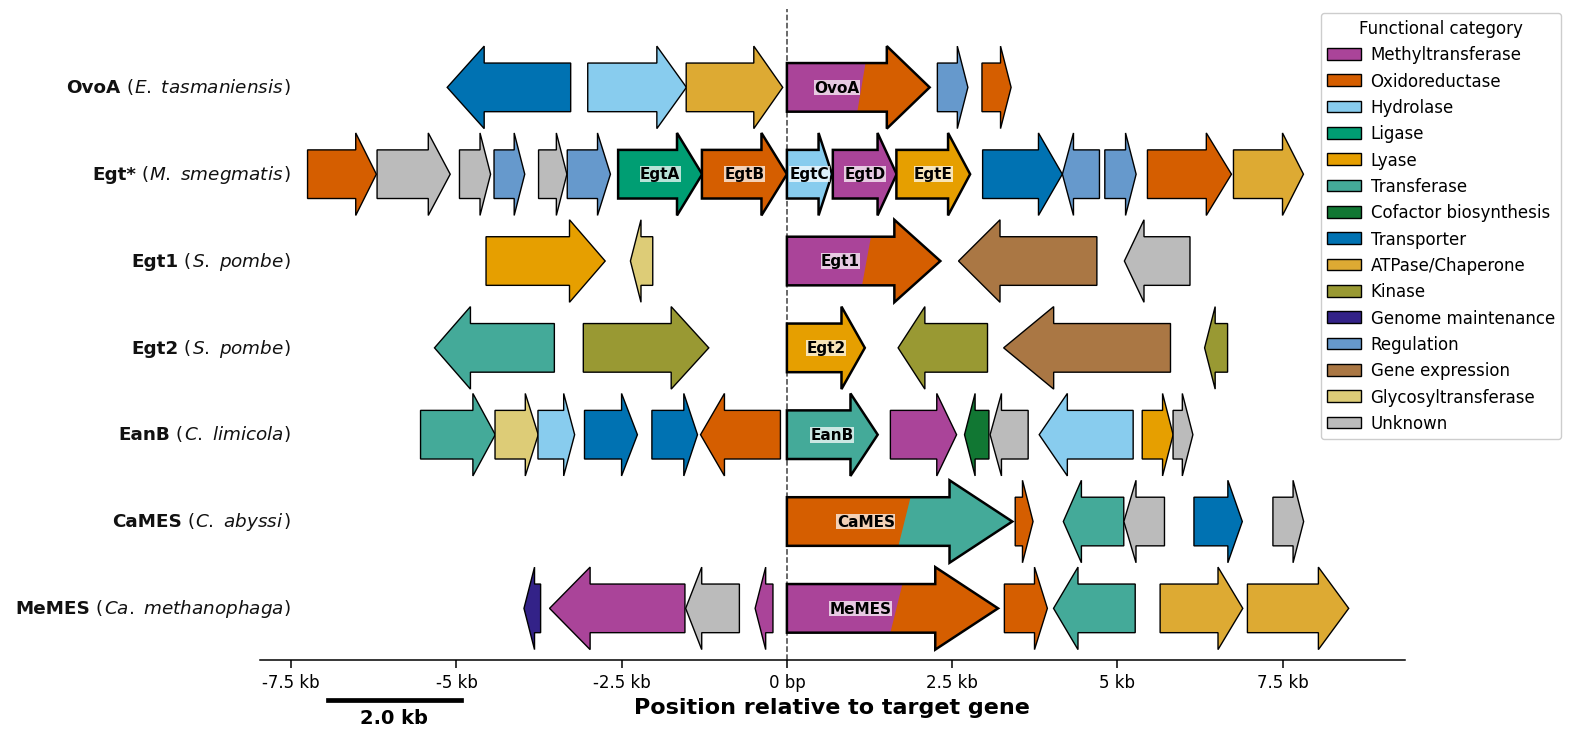

In [11]:
with open('gene_neighborhoods_results.json', 'r', encoding='utf-8') as f:
    plotting_data = json.load(f)

escape_fn = globals().get('_row_label_math_escape', lambda text: str(text))
for entry in plotting_data:
    organism = entry.get('organism', '')
    entry['organism'] = f"$\\it{{{escape_fn(organism)}}}$"

plot_neighborhoods(plotting_data, 'gene_neighborhoods.pdf')